# Sistema de Recomendação de Imóveis para a Cidade de Maputo

O mercado imobiliário tem registado um crescimento significativo nos últimos anos, impulsionado pela crescente procura de habitações, espaços comerciais e oportunidades de investimento. Paralelamente, o aumento da quantidade de anúncios disponíveis em plataformas digitais tornou o processo de procura de imóveis mais complexo para os potenciais compradores e arrendatários. Neste contexto, os sistemas de recomendação surgem como uma solução capaz de auxiliar os utilizadores na identificação de imóveis alinhados com as suas preferências e necessidades.

Este projecto tem como objectivo desenvolver e avaliar um sistema de recomendação de imóveis para a Cidade de Maputo, recorrendo a técnicas de Machine Learning e análise de similaridade. O sistema procura identificar padrões nas características dos imóveis e gerar recomendações personalizadas, facilitando o processo de descoberta de opções relevantes para os utilizadores.

Para a implementação do projecto foi utilizada uma base de dados composta por anúncios imobiliários contendo informações como preço, localização, dimensão, número de quartos, estado do imóvel, características adicionais e descrições textuais. Os dados passaram por um processo de limpeza, transformação e preparação, visando melhorar a sua qualidade e adequação aos modelos desenvolvidos.

### Objectivos Específicos

* Realizar a limpeza, transformação e preparação dos dados imobiliários.
* Explorar os dados através de técnicas de Análise Exploratória de Dados (EDA).
* Extrair e representar características estruturadas e textuais dos imóveis.
* Aplicar técnicas de agrupamento para identificar perfis semelhantes de imóveis.
* Implementar sistemas de recomendação baseados em conteúdo e em similaridade.
* Avaliar o desempenho dos modelos utilizando métricas apropriadas para recomendação.
* Comparar as abordagens desenvolvidas e seleccionar o modelo com melhor desempenho.
* Produzir conclusões e recomendações para futuras melhorias do sistema.

---

<img src="../assets/capa vi.png">

---

# *I. Base*

### Bibliotecas Usadas

In [1]:
# ============================================================
# BIBLIOTECAS PADRÃO
# ============================================================

import os
import re
import warnings

warnings.filterwarnings("ignore")

# ============================================================
# MANIPULAÇÃO DE DADOS
# ============================================================

import numpy as np
import pandas as pd

pd.set_option("display.max_columns", None)

# ============================================================
# VISUALIZAÇÃO
# ============================================================

import matplotlib.pyplot as plt

# ============================================================
# ANÁLISE ESTATÍSTICA
# ============================================================

from scipy import stats

# ============================================================
# REDUÇÃO DE DIMENSIONALIDADE
# ============================================================

from sklearn.decomposition import PCA

# ============================================================
# PRÉ-PROCESSAMENTO
# ============================================================

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

# ============================================================
# PROCESSAMENTO DE TEXTO (NLP)
# ============================================================

from sklearn.feature_extraction.text import TfidfVectorizer

# ============================================================
# CLUSTERIZAÇÃO
# ============================================================

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# ============================================================
# RECOMENDAÇÃO
# ============================================================

from sklearn.neighbors import NearestNeighbors
from sklearn.metrics.pairwise import cosine_similarity

# ============================================================
# PERSISTÊNCIA DE MODELOS
# ============================================================

import joblib

### Funções Principais

In [37]:
def analisar_qualidade(df, df_caminho):
    """
    Realiza uma análise básica da qualidade de um dataset,
    apresentando informações sobre dimensões, uso de memória,
    valores ausentes, duplicados, tipos de dados e estatísticas
    descritivas das colunas numéricas.
    """
    
    # Dimensões básicas
    total_linhas = df.shape[0]
    total_colunas = df.shape[1]
    total_celulas = total_linhas * total_colunas
    
    # Tamanho em memória
    tamanho_mb_dico = os.path.getsize(df_caminho) / 1024**2
    tamanho_mb_memoria = df.memory_usage(deep=True).sum() / (1024 ** 2)
    
    
    # Valores ausentes
    valores_ausentes = df.isnull().sum().sum()
    percentagem_ausentes = (valores_ausentes / total_celulas) * 100
    
    # Duplicados
    duplicados = df.duplicated().sum()
    percentagem_duplicados = (duplicados / total_linhas) * 100
    
    # Dados válidos
    dados_validos = total_celulas - valores_ausentes
    percentagem_validos = (dados_validos / total_celulas) * 100
    
    # Linhas completas (sem valores ausentes)
    linhas_completas = df.dropna().shape[0]
    percentagem_linhas_completas = (linhas_completas / total_linhas) * 100
    
    # Linhas incompletas (com valores ausentes)
    linhas_incompletas = total_linhas - linhas_completas
    percentagem_linhas_incompletas = (linhas_incompletas / total_linhas) * 100
    
    # EXIBIÇÃO DE RESULTADOS
    print("=" * 70)
    print("ANÁLISE DE QUALIDADE DO DATASET")
    print("=" * 70)
    
    # Detalhes gerais
    print("\n DETALHES GERAIS")
    print("-" * 70)
    print(f"Total de linhas: {total_linhas:,}")
    print(f"Total de colunas: {total_colunas}")
    print(f"Total de células: {total_celulas:,}")
    print(f"Tamanho do dataset (em disco): {tamanho_mb_dico:.1f} MB")
    print(f"Tamanho do dataset (em memória): {tamanho_mb_memoria:.1f} MB")
    
    # Tabela de métricas principais
    print("\n RESUMO DA QUALIDADE DOS DADOS")
    print("-" * 70)
    
    metricas = pd.DataFrame({
        "Métrica": [
            "Valores ausentes",
            "Duplicados",
            "Dados válidos",
            "Linhas completas",
            "Linhas incompletas"
        ],
        "Quantidade": [
            valores_ausentes,
            duplicados,
            dados_validos,
            linhas_completas,
            linhas_incompletas
        ],
        "Percentagem (%)": [
            f"{percentagem_ausentes:.1f}%",
            f"{percentagem_duplicados:.1f}%",
            f"{percentagem_validos:.1f}%",
            f"{percentagem_linhas_completas:.1f}%",
            f"{percentagem_linhas_incompletas:.1f}%"
        ]
    })
    
    print(metricas.to_string(index=False))
    
    # Valores ausentes por coluna
    print("\n VALORES AUSENTES POR COLUNA")
    print("-" * 70)
    
    ausentes_coluna = df.isnull().sum()
    percentagem_coluna = (ausentes_coluna / total_linhas) * 100
    
    tabela_ausentes = pd.DataFrame({
        "Coluna": df.columns,
        "Valores Ausentes": ausentes_coluna.values,
        "Percentagem (%)": [f"{p:.1f}%" for p in percentagem_coluna.values]
    })
    
    print(tabela_ausentes.to_string(index=False))
    
    # Tipos de dados
    print("\n TIPOS DE DADOS")
    print("-" * 70)
    print(df.dtypes)
    
# ============================================================================================

def extrair_features(texto):
    """
    Extrai características estruturadas a partir da descrição textual de um imóvel.

    A função utiliza expressões regulares para identificar informações relevantes
    presentes na descrição, convertendo texto não estruturado em variáveis
    quantitativas e binárias que podem ser utilizadas em análises exploratórias,
    modelação preditiva e sistemas de recomendação imobiliária.

    Features extraídas
    ------------------
    Variáveis numéricas:
        - quartos: número de quartos identificado a partir da tipologia
          (ex.: T2, T3, T4).
        - casas_banho: número de casas de banho mencionadas.
        - lugares_garagem: capacidade da garagem, quando especificada.
        - area_mencionada: maior área encontrada na descrição, em metros quadrados.

    Variáveis binárias (0/1):
        Lazer:
            - piscina
            - jardim
            - quintal
            - churrasqueira
            - campo_futebol
            - ginasio

        Segurança:
            - seguranca_24h
            - porteiro
            - guarita
            - condominio

        Conforto:
            - mobilado
            - ar_condicionado
            - ventilador
            - internet
            - tv_cabo

        Infra-estruturas:
            - garagem
            - estacionamento
            - elevador
            - gerador
            - reservatorio_agua
            - furo_agua
            - poco

        Extras:
            - anexo
            - escritorio
            - lavandaria
            - despensa
            - varanda
            - terraco
            - suite

        Localização:
            - vista_mar
            - vista_rio
            - frente_mar

        Qualidade:
            - luxo
            - nova
            - remodelada
            - recente

        Energia:
            - energia_solar

    Parâmetros
    ----------
    texto : str ou NaN
        Descrição textual do imóvel.

    Retorna
    -------
    pandas.Series
        Série contendo as características extraídas da descrição do imóvel.

    Exemplos
    --------
    >>> extrair_features(
    ...     "Moradia T4 com 3 casas de banho, piscina, jardim e garagem para 2 carros."
    ... )
    quartos             4
    casas_banho         3
    lugares_garagem     2
    piscina             1
    jardim              1
    garagem             1
    ...

    Notas
    -----
    - Caso a descrição seja nula (NaN), será convertida para uma string vazia.
    - Quando múltiplas áreas forem encontradas, é seleccionada a maior.
    - As variáveis binárias assumem valor 1 quando a característica é detectada
      e 0 caso contrário.
    """

    if pd.isna(texto):
        texto = ""

    texto = str(texto).lower()

    f = {}

    # =====================================================
    # TIPOLOGIA
    # =====================================================

    m = re.search(r'\bt\s*(\d+)\b', texto)
    f["quartos"] = int(m.group(1)) if m else np.nan

    # =====================================================
    # CASAS DE BANHO
    # =====================================================

    m = re.search(
        r'(\d+)\s*(wc|wcs|casas?\s*de\s*banho|banheiros?)',
        texto
    )

    f["casas_banho"] = int(m.group(1)) if m else np.nan

    # =====================================================
    # GARAGEM
    # =====================================================

    m = re.search(
        r'garagem\s*(?:para)?\s*(\d+)',
        texto
    )

    f["lugares_garagem"] = int(m.group(1)) if m else 0

    # =====================================================
    # ÁREA
    # =====================================================

    areas = re.findall(r'(\d+)\s*m2', texto)

    if areas:
        areas = [int(x) for x in areas]
        f["area_mencionada"] = max(areas)
    else:
        f["area_mencionada"] = np.nan

    # =====================================================
    # FEATURES BINÁRIAS
    # =====================================================

    keywords = {

        # lazer
        "piscina": r'\bpiscina\b',
        "jardim": r'\bjardim\b',
        "quintal": r'\bquintal\b',
        "churrasqueira": r'churrasqueira',
        "campo_futebol": r'campo\s+de\s+futebol',
        "ginasio": r'g[ií]nasio|academia',

        # segurança
        "seguranca_24h": r'seguran[cç]a\s*24h',
        "porteiro": r'porteiro',
        "guarita": r'guarita',
        "condominio": r'condom[ií]nio',

        # conforto
        "mobilado": r'mobilad',
        "ar_condicionado": r'ar\s*condicionado',
        "ventilador": r'ventilador',
        "internet": r'internet|wifi|wi-fi',
        "tv_cabo": r'tv\s*cabo',

        # infraestruturas
        "garagem": r'garagem',
        "estacionamento": r'estacionamento',
        "elevador": r'elevador',
        "gerador": r'gerador',
        "reservatorio_agua": r'reservat[oó]rio',
        "furo_agua": r'furo',
        "poco": r'po[cç]o',

        # extras
        "anexo": r'anexo',
        "escritorio": r'escrit[oó]rio',
        "lavandaria": r'lavandaria',
        "despensa": r'despensa',
        "varanda": r'varanda',
        "terraco": r'terra[cç]o',
        "suite": r'suite|su[ií]te',

        # localização
        "vista_mar": r'vista\s+mar',
        "vista_rio": r'vista\s+rio',
        "frente_mar": r'frente\s+ao\s+mar',

        # qualidade
        "luxo": r'luxo|luxuosa|luxuoso',
        "nova": r'\bnova\b|\bnovo\b',
        "remodelada": r'remodelad',
        "recente": r'recente',

        # energia
        "energia_solar": r'energia\s+solar|pain[eé]is?\s+solares?',
    }

    for nome, regex in keywords.items():
        f[nome] = int(bool(re.search(regex, texto)))

    return pd.Series(f)

# ============================================================================================

def gerar_estatisticas_valor(df, coluna='valor'):
    """
    Gera uma tabela de estatísticas descritivas para uma coluna de valores monetários.

    Parâmetros
    ----------
    df : pandas.DataFrame
        DataFrame contendo os dados dos imóveis.

    coluna : str, opcional (default='valor')
        Nome da coluna que contém os valores a serem analisados.

    Retorna
    -------
    pandas.DataFrame
        DataFrame com as seguintes métricas:
        - Quantidade de registos válidos
        - Valores ausentes
        - Mínimo
        - 1º Quartil (25%)
        - Mediana (50%)
        - 3º Quartil (75%)
        - Máximo
        - Média
        - Desvio Padrão

        Os valores monetários são formatados no padrão:
        1.234.567,89 MZN
    """

    # Converter para numérico e remover inválidos
    valores = pd.to_numeric(df[coluna], errors='coerce').dropna()

    estatisticas = pd.DataFrame({
        'Métrica': [
            'Quantidade',
            'Valores Ausentes',
            'Mínimo',
            '1º Quartil (25%)',
            'Mediana (50%)',
            '3º Quartil (75%)',
            'Máximo',
            'Média',
            'Desvio Padrão'
        ],
        'Valor': [
            len(valores),
            df[coluna].isna().sum(),
            valores.min(),
            valores.quantile(0.25),
            valores.median(),
            valores.quantile(0.75),
            valores.max(),
            valores.mean(),
            valores.std()
        ]
    })

    metricas_monetarias = [
        'Mínimo',
        '1º Quartil (25%)',
        'Mediana (50%)',
        '3º Quartil (75%)',
        'Máximo',
        'Média',
        'Desvio Padrão'
    ]

    def formatar_mzn(valor):
        return (
            f"{valor:,.2f}"
            .replace(",", "X")
            .replace(".", ",")
            .replace("X", ".")
            + " MZN"
        )

    estatisticas['Valor'] = estatisticas.apply(
        lambda row: formatar_mzn(row['Valor'])
        if row['Métrica'] in metricas_monetarias
        else f"{int(row['Valor']):,}".replace(",", "."),
        axis=1
    )

    return estatisticas

# ============================================================================================

def gerar_distribuicao_precos(
    df,
    coluna='valor',
    bins=None,
    labels=None
):
    """
    Gera uma tabela com a distribuição dos imóveis por faixa de preço.

    Parâmetros
    ----------
    df : pandas.DataFrame
        DataFrame contendo os dados.

    coluna : str, opcional (default='valor')
        Nome da coluna com os preços dos imóveis.

    bins : list, opcional
        Limites das faixas de preço. Caso não seja informado,
        utiliza:
        [0, 100000, 300000, 600000, 1000000]

    labels : list, opcional
        Rótulos das faixas de preço. Caso não seja informado,
        utiliza:
        ['Até 100k', '100k - 300k', '300k - 600k', '600k - 1M']

    Retorna
    -------
    pandas.DataFrame
        Tabela contendo:
        - Faixa de Preço
        - Quantidade
        - Percentual (%)

        Os valores são formatados para apresentação.
    """

    if bins is None:
        bins = [0, 100_000, 300_000, 600_000, 1_000_000]

    if labels is None:
        labels = [
            'Até 100k',
            '100k - 300k',
            '300k - 600k',
            '600k - 1M'
        ]

    # Garantir tipo numérico
    valores = pd.to_numeric(df[coluna], errors='coerce')

    # Classificação em faixas
    faixas = pd.cut(
        valores,
        bins=bins,
        labels=labels,
        include_lowest=True
    )

    tabela = pd.DataFrame({
        'Quantidade': faixas.value_counts().sort_index()
    })

    tabela['Percentual (%)'] = (
        tabela['Quantidade']
        / tabela['Quantidade'].sum()
        * 100
    ).round(2)

    tabela = tabela.reset_index()
    tabela.columns = [
        'Faixa de Preço',
        'Quantidade',
        'Percentual (%)'
    ]

    # Formatação
    tabela['Quantidade'] = (
        tabela['Quantidade']
        .apply(lambda x: f'{x:,}'.replace(',', '.'))
    )

    tabela['Percentual (%)'] = (
        tabela['Percentual (%)']
        .apply(lambda x: f'{x:.2f}'.replace('.', ','))
    )

    return tabela

# ============================================================================================

def analisar_distribuicao_precos(
    df,
    coluna='valor',
    bins=30,
    figsize=(16, 12)
):
    """
    Gera gráficos para análise da distribuição dos preços dos imóveis.

    Parâmetros
    ----------
    df : pandas.DataFrame
        DataFrame contendo os dados.

    coluna : str, opcional (default='valor')
        Nome da coluna com os valores dos imóveis.

    bins : int, opcional (default=30)
        Número de classes utilizadas nos histogramas.

    figsize : tuple, opcional (default=(16, 12))
        Tamanho da figura.

    Gráficos Gerados
    ----------------
    1. Histograma dos valores originais.
    2. Boxplot para identificação de outliers.
    3. Histograma dos valores transformados em log.
    4. Q-Q Plot para avaliação da normalidade.

    Retorna
    -------
    matplotlib.figure.Figure
        Figura contendo os quatro gráficos.

    matplotlib.axes._subplots.ndarray
        Conjunto de eixos utilizados nos gráficos.
    """

    # Converter para numérico e remover ausentes
    valores = pd.to_numeric(
        df[coluna],
        errors='coerce'
    ).dropna()

    # Transformação logarítmica
    valores_log = np.log1p(valores)

    # Paleta de cores
    cores = {
        'hist': '#2563EB',      # azul moderno
        'box': '#F59E0B',       # âmbar
        'log': '#10B981',       # verde esmeralda
        'qq': '#8B5CF6'         # roxo
    }

    # Criar figura
    fig, axes = plt.subplots(
        2,
        2,
        figsize=figsize
    )

    fig.suptitle(
        'Análise da Distribuição dos Preços dos Imóveis',
        fontsize=18,
        fontweight='bold'
    )

    # ==========================
    # 1. Histograma
    # ==========================
    axes[0, 0].hist(
        valores,
        bins=bins,
        color=cores['hist'],
        edgecolor='white',
        alpha=0.85
    )
    axes[0, 0].set_title(
        'Distribuição dos Valores',
        fontweight='bold'
    )
    axes[0, 0].set_xlabel('Valor (MZN)')
    axes[0, 0].set_ylabel('Frequência')
    axes[0, 0].grid(
        alpha=0.2,
        linestyle='--'
    )

    # ==========================
    # 2. Boxplot
    # ==========================
    axes[0, 1].boxplot(
        valores,
        patch_artist=True,
        boxprops=dict(
            facecolor=cores['box'],
            alpha=0.8
        ),
        medianprops=dict(
            color='black',
            linewidth=2
        )
    )
    axes[0, 1].set_title(
        'Boxplot dos Valores',
        fontweight='bold'
    )
    axes[0, 1].set_ylabel('Valor (MZN)')
    axes[0, 1].grid(
        alpha=0.2,
        linestyle='--'
    )

    # ==========================
    # 3. Histograma Log
    # ==========================
    axes[1, 0].hist(
        valores_log,
        bins=bins,
        color=cores['log'],
        edgecolor='white',
        alpha=0.85
    )
    axes[1, 0].set_title(
        'Distribuição Logarítmica',
        fontweight='bold'
    )
    axes[1, 0].set_xlabel('log(Valor + 1)')
    axes[1, 0].set_ylabel('Frequência')
    axes[1, 0].grid(
        alpha=0.2,
        linestyle='--'
    )

    # ==========================
    # 4. Q-Q Plot
    # ==========================
    stats.probplot(
        valores,
        dist='norm',
        plot=axes[1, 1]
    )

    # Recolorir elementos do Q-Q Plot
    axes[1, 1].get_lines()[0].set_markerfacecolor(
        cores['qq']
    )
    axes[1, 1].get_lines()[0].set_markeredgecolor(
        cores['qq']
    )
    axes[1, 1].get_lines()[1].set_color(
        '#DC2626'
    )

    axes[1, 1].set_title(
        'Q-Q Plot (Normalidade)',
        fontweight='bold'
    )
    axes[1, 1].grid(
        alpha=0.2,
        linestyle='--'
    )

    plt.tight_layout()

    return fig, axes

# ============================================================================================

def analisar_estado_tipo_imoveis(
    df,
    coluna_valor='valor',
    coluna_estado='estado',
    coluna_tipo='tipo_base',
    figsize=(18, 12)
):
    """
    Gera uma análise comparativa dos imóveis por estado e tipo.

    Parâmetros
    ----------
    df : pandas.DataFrame
        DataFrame contendo os dados dos imóveis.

    coluna_valor : str, opcional (default='valor')
        Coluna que contém o valor dos imóveis.

    coluna_estado : str, opcional (default='estado')
        Coluna que identifica o estado do imóvel
        (novo, usado, em construção, etc.).

    coluna_tipo : str, opcional (default='tipo_base')
        Coluna que identifica o tipo de imóvel
        (apartamento, moradia, terreno, etc.).

    figsize : tuple, opcional (default=(18, 12))
        Tamanho da figura.

    Gráficos Gerados
    ----------------
    1. Valor médio dos imóveis por estado.
    2. Quantidade de imóveis por estado.
    3. Valor médio dos imóveis por tipo.
    4. Quantidade de imóveis por tipo.

    Retorna
    -------
    fig : matplotlib.figure.Figure
        Figura criada.

    axes : numpy.ndarray
        Matriz de eixos dos gráficos.
    """

    import pandas as pd
    import matplotlib.pyplot as plt

    # =====================================================
    # Estilo e paleta
    # =====================================================
    plt.style.use('seaborn-v0_8-whitegrid')

    cores = {
        'valor_estado': '#2563EB',      # Azul
        'qtd_estado': '#F59E0B',        # Âmbar
        'valor_tipo': '#10B981',        # Verde
        'qtd_tipo': '#8B5CF6'           # Roxo
    }

    # =====================================================
    # Preparação dos dados
    # =====================================================
    dados = df.copy()

    dados[coluna_valor] = pd.to_numeric(
        dados[coluna_valor],
        errors='coerce'
    )

    fig, axes = plt.subplots(
        2,
        2,
        figsize=figsize
    )

    fig.suptitle(
        'Análise Comparativa dos Imóveis por Estado e Tipo',
        fontsize=18,
        fontweight='bold',
        y=1.02
    )

    # =====================================================
    # 1. Valor médio por estado
    # =====================================================
    media_estado = (
        dados.groupby(coluna_estado)[coluna_valor]
        .mean()
        .sort_values(ascending=False)
    )

    bars = axes[0, 0].bar(
        media_estado.index,
        media_estado.values,
        color=cores['valor_estado'],
        alpha=0.9,
        edgecolor='white',
        linewidth=1
    )

    axes[0, 0].set_title(
        'Valor Médio dos Imóveis por Estado',
        fontweight='bold'
    )

    axes[0, 0].set_ylabel('Valor Médio (MZN)')
    axes[0, 0].tick_params(axis='x', rotation=45)
    axes[0, 0].grid(axis='y', alpha=0.3)

    for bar in bars:
        y = bar.get_height()
        axes[0, 0].text(
            bar.get_x() + bar.get_width() / 2,
            y,
            f'{y:,.0f}'.replace(',', '.'),
            ha='center',
            va='bottom',
            fontsize=9,
            fontweight='bold'
        )

    # =====================================================
    # 2. Quantidade por estado
    # =====================================================
    dist_estado = (
        dados[coluna_estado]
        .value_counts()
        .sort_values(ascending=False)
    )

    bars = axes[0, 1].bar(
        dist_estado.index,
        dist_estado.values,
        color=cores['qtd_estado'],
        alpha=0.9,
        edgecolor='white',
        linewidth=1
    )

    axes[0, 1].set_title(
        'Quantidade de Imóveis por Estado',
        fontweight='bold'
    )

    axes[0, 1].set_ylabel('Quantidade')
    axes[0, 1].tick_params(axis='x', rotation=45)
    axes[0, 1].grid(axis='y', alpha=0.3)

    for bar in bars:
        y = bar.get_height()
        axes[0, 1].text(
            bar.get_x() + bar.get_width() / 2,
            y,
            f'{int(y):,}'.replace(',', '.'),
            ha='center',
            va='bottom',
            fontsize=9,
            fontweight='bold'
        )

    # =====================================================
    # 3. Valor médio por tipo
    # =====================================================
    media_tipo = (
        dados.groupby(coluna_tipo)[coluna_valor]
        .mean()
        .sort_values(ascending=False)
    )

    bars = axes[1, 0].bar(
        media_tipo.index,
        media_tipo.values,
        color=cores['valor_tipo'],
        alpha=0.9,
        edgecolor='white',
        linewidth=1
    )

    axes[1, 0].set_title(
        'Valor Médio dos Imóveis por Tipo',
        fontweight='bold'
    )

    axes[1, 0].set_ylabel('Valor Médio (MZN)')
    axes[1, 0].set_xlabel('Tipo')
    axes[1, 0].tick_params(axis='x', rotation=45)
    axes[1, 0].grid(axis='y', alpha=0.3)

    for bar in bars:
        y = bar.get_height()
        axes[1, 0].text(
            bar.get_x() + bar.get_width() / 2,
            y,
            f'{y:,.0f}'.replace(',', '.'),
            ha='center',
            va='bottom',
            fontsize=9,
            fontweight='bold'
        )

    # =====================================================
    # 4. Quantidade por tipo
    # =====================================================
    dist_tipo = (
        dados[coluna_tipo]
        .value_counts()
        .sort_values(ascending=False)
    )

    bars = axes[1, 1].bar(
        dist_tipo.index,
        dist_tipo.values,
        color=cores['qtd_tipo'],
        alpha=0.9,
        edgecolor='white',
        linewidth=1
    )

    axes[1, 1].set_title(
        'Quantidade de Imóveis por Tipo',
        fontweight='bold'
    )

    axes[1, 1].set_ylabel('Quantidade')
    axes[1, 1].set_xlabel('Tipo')
    axes[1, 1].tick_params(axis='x', rotation=45)
    axes[1, 1].grid(axis='y', alpha=0.3)

    for bar in bars:
        y = bar.get_height()
        axes[1, 1].text(
            bar.get_x() + bar.get_width() / 2,
            y,
            f'{int(y):,}'.replace(',', '.'),
            ha='center',
            va='bottom',
            fontsize=9,
            fontweight='bold'
        )

    plt.tight_layout()

    return fig, axes

# ============================================================================================

def plotar_mapa_imoveis(
    df,
    coluna_latitude='latitude',
    coluna_longitude='longitude',
    coluna_valor='valor',
    figsize=(12, 8),
    cmap='viridis'
):
    """
    Gera um mapa de dispersão geográfica dos imóveis,
    colorindo os pontos de acordo com o valor do imóvel.

    Parâmetros
    ----------
    df : pandas.DataFrame
        DataFrame contendo os imóveis.

    coluna_latitude : str, opcional (default='latitude')
        Nome da coluna de latitude.

    coluna_longitude : str, opcional (default='longitude')
        Nome da coluna de longitude.

    coluna_valor : str, opcional (default='valor')
        Nome da coluna que contém o valor do imóvel.

    figsize : tuple, opcional (default=(12, 8))
        Tamanho da figura.

    cmap : str, opcional (default='viridis')
        Mapa de cores utilizado na visualização.

    Retorna
    -------
    fig : matplotlib.figure.Figure
        Figura criada.

    ax : matplotlib.axes.Axes
        Eixo do gráfico.

    Observações
    -----------
    Os valores são transformados usando log10 para melhorar
    a visualização quando existem grandes diferenças de preço.
    """

    dados = df.copy()

    # Garantir tipos numéricos
    dados[coluna_latitude] = pd.to_numeric(
        dados[coluna_latitude],
        errors='coerce'
    )

    dados[coluna_longitude] = pd.to_numeric(
        dados[coluna_longitude],
        errors='coerce'
    )

    dados[coluna_valor] = pd.to_numeric(
        dados[coluna_valor],
        errors='coerce'
    )

    # Remover registos inválidos
    dados = dados.dropna(
        subset=[
            coluna_latitude,
            coluna_longitude,
            coluna_valor
        ]
    )

    # Remover valores não positivos
    dados = dados[
        dados[coluna_valor] > 0
    ]

    fig, ax = plt.subplots(figsize=figsize)

    scatter = ax.scatter(
        dados[coluna_longitude],
        dados[coluna_latitude],
        c=np.log10(dados[coluna_valor]),
        cmap=cmap,
        alpha=0.6,
        s=50,
        edgecolor='black',
        linewidth=0.5
    )

    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_title(
        'Localização Geográfica dos Imóveis'
    )

    cbar = plt.colorbar(
        scatter,
        ax=ax
    )
    cbar.set_label('Log10(Valor)')

    plt.tight_layout()

    return fig, ax

# ============================================================================================

def analisar_caracteristicas_imoveis(
    df,
    prefixo='feature_',
    top_n=15,
    figsize=(12, 8)
):
    """
    Gera um gráfico com as características mais comuns dos imóveis.

    Parâmetros
    ----------
    df : pandas.DataFrame
        DataFrame contendo os dados dos imóveis.

    prefixo : str, opcional (default='feature_')
        Prefixo utilizado para identificar as colunas de
        características.

    top_n : int, opcional (default=15)
        Número de características a apresentar.

    figsize : tuple, opcional (default=(12, 8))
        Tamanho da figura.

    Retorna
    -------
    pandas.DataFrame
        Tabela com as características e respectivas contagens.

    fig : matplotlib.figure.Figure
        Figura criada.

    ax : matplotlib.axes.Axes
        Eixo do gráfico.

    Observações
    -----------
    Assume que as colunas de características são binárias
    (0/1 ou True/False), indicando a presença ou ausência
    de determinada característica no imóvel.
    """

    # Identificar colunas de características
    feature_cols = [
        c for c in df.columns
        if c.startswith(prefixo)
    ]

    if len(feature_cols) == 0:
        raise ValueError(
            f'Nenhuma coluna encontrada com o prefixo "{prefixo}".'
        )

    # Contagem das características
    contagem = (
        df[feature_cols]
        .fillna(0)
        .astype(int)
        .sum()
        .sort_values(ascending=False)
        .head(top_n)
    )

    # Formatar nomes
    contagem.index = (
        contagem.index
        .str.replace(prefixo, '', regex=False)
        .str.replace('_', ' ')
        .str.title()
    )

    tabela = (
        contagem
        .reset_index()
        .rename(
            columns={
                'index': 'Característica',
                0: 'Quantidade'
            }
        )
    )

    tabela.columns = [
        'Característica',
        'Quantidade'
    ]

    # Gráfico
    fig, ax = plt.subplots(figsize=figsize)

    bars = ax.barh(
        contagem.index[::-1],
        contagem.values[::-1]
    )

    ax.set_title(
        f'Top {top_n} Características Mais Comuns dos Imóveis'
    )
    ax.set_xlabel('Quantidade de Imóveis')
    ax.set_ylabel('Característica')

    # Adicionar rótulos
    for bar in bars:
        largura = bar.get_width()

        ax.text(
            largura + max(contagem.values) * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f'{int(largura):,}'.replace(',', '.'),
            va='center'
        )

    plt.tight_layout()

    return tabela, fig, ax

# ============================================================================================

def analisar_correlacao_valor(
    df,
    coluna_alvo='valor',
    coluna_area='dimensao (m²)',
    figsize_base=(12, 8)
):
    """
    Calcula e visualiza a correlação entre o valor do imóvel
    e as demais variáveis numéricas disponíveis.

    Parâmetros
    ----------
    df : pandas.DataFrame
        DataFrame contendo os dados dos imóveis.

    coluna_alvo : str, opcional (default='valor')
        Coluna que representa o valor do imóvel.

    coluna_area : str, opcional (default='dimensao (m²)')
        Coluna da área/dimensão do imóvel.

    figsize_base : tuple, opcional (default=(12, 8))
        Tamanho base da figura.

    Retorna
    -------
    pandas.DataFrame
        Tabela com as correlações ordenadas.

    fig : matplotlib.figure.Figure
        Figura criada.

    ax : matplotlib.axes.Axes
        Eixo do gráfico.

    Observações
    -----------
    Utiliza o coeficiente de correlação de Pearson.

    Valores próximos de:
    - 1   : forte correlação positiva
    - 0   : ausência de correlação linear
    - -1  : forte correlação negativa
    """

    dados = df.copy()

    # Identificar colunas de features
    feature_cols = [
        c for c in dados.columns
        if c.startswith('feature_')
    ]

    colunas = [
        coluna_alvo,
        coluna_area,
        'feature_quartos',
        'feature_casas_banho',
        'feature_lugares_garagem',
        'latitude',
        'longitude'
    ] + feature_cols

    # Manter apenas colunas existentes
    colunas = [
        c for c in colunas
        if c in dados.columns
    ]

    # Converter para numérico
    for col in colunas:
        dados[col] = pd.to_numeric(
            dados[col],
            errors='coerce'
        )

    # Matriz de correlação
    corr_valor = (
        dados[colunas]
        .corr(numeric_only=True)[coluna_alvo]
        .drop(coluna_alvo)
        .dropna()
        .sort_values()
    )

    tabela = (
        corr_valor
        .reset_index()
        .rename(
            columns={
                'index': 'Variável',
                coluna_alvo: 'Correlação'
            }
        )
    )

    altura = max(
        figsize_base[1],
        len(corr_valor) * 0.35
    )

    fig, ax = plt.subplots(
        figsize=(figsize_base[0], altura)
    )

    bars = ax.barh(
        corr_valor.index,
        corr_valor.values
    )

    ax.set_title(
        'Correlação das Variáveis com o Valor do Imóvel'
    )

    ax.set_xlabel(
        'Coeficiente de Correlação de Pearson'
    )

    ax.axvline(
        0,
        color='black',
        linewidth=1
    )

    # Adicionar rótulos
    for bar in bars:

        valor = bar.get_width()

        ax.text(
            valor + 0.01 if valor >= 0 else valor - 0.01,
            bar.get_y() + bar.get_height() / 2,
            f'{valor:.2f}',
            va='center',
            ha='left' if valor >= 0 else 'right'
        )

    plt.tight_layout()

    return tabela, fig, ax

# ============================================================================================

"""
==================================================
Modelo KMeans
==================================================

Pipeline completo que:
1. Carrega e limpa o dataset de imóveis (trata valores ausentes, valores
   sentinela como -1, e cria duas colunas derivadas: tipo_transacao e
   valor_log — ver "Notas sobre os dados" abaixo)
2. Pré-processa colunas numéricas, binárias (feature_*) e categóricas
3. Encontra o número ideal de clusters (método do cotovelo + silhouette score)
4. Treina o modelo KMeans final
5. Recomenda imóveis semelhantes a um imóvel de referência (por id)
   OU a partir de um conjunto de preferências do utilizador
6. Salva e recarrega o modelo treinado

Notas sobre os dados (importante):
- "estado" não é uma localização/província: neste dataset representa a
  CONDIÇÃO do imóvel (Usado, Novo, Renovado, Recuperado, Em construção).
  A localização vem apenas de latitude/longitude.
- "valor" mistura arrendamentos (ex.: 65.000 MZN/mês) com vendas
  (ex.: 170.000.000 MZN).
  Essa diferença de escala (3 mil a 170 milhões) domina
  completamente a distância euclidiana do KMeans e distorce os clusters.
  Por isso o script:
    a) extrai um "tipo_transacao" (Aluguer / Venda / desconhecido) a partir
       do texto da descrição, e usa-o como variável categórica
    b) aplica log1p ao valor antes de o escalar, para reduzir a assimetria
  Por padrão, as recomendações também só comparam imóveis do mesmo tipo de
  transação (não tem sentido recomendar uma venda de 170M MZN a quem
  procura um arrendamento).
- "quartos_base" usa -1 como valor sentinela para "não especificado"; o
  script converte isso para NaN antes de imputar.
- "dimensao (m²)" tem bastantes valores ausentes; quando possível, o script
  usa "feature_area_mencionada" (área mencionada no texto) como substituto
  antes de recorrer à mediana.
"""


# ---------------------------------------------------------------------------
# 1. CONFIGURAÇÃO
# ---------------------------------------------------------------------------

COLUNA_ID = "id"

# Colunas numéricas usadas no modelo. Note que usamos "valor_log" (derivada
# do "valor" original) em vez do valor bruto — ver "Notas sobre os dados".
COLUNAS_NUMERICAS = [
    "valor_log",
    "latitude",
    "longitude",
    "dimensao (m²)",
    "quartos_base",
]

# Colunas categóricas a codificar com One-Hot Encoding.
# "estado" = condição do imóvel (Usado/Novo/Renovado/...), não localização.
# "tipo_transacao" é derivada do texto da descrição (ver detectar_tipo_transacao).
COLUNAS_CATEGORICAS = [
    "estado",
    "tipo_base",
    "tipo_transacao",
]

# Colunas numéricas/contagens extraídas do texto da descrição (algumas são
# 0/1, outras são contagens como nº de quartos ou m² mencionados). Todas
# entram padronizadas (StandardScaler), por isso tratá-las juntas é seguro.
COLUNAS_BINARIAS = [
    "feature_quartos", "feature_casas_banho", "feature_lugares_garagem",
    "feature_area_mencionada", "feature_piscina", "feature_jardim",
    "feature_quintal", "feature_churrasqueira", "feature_campo_futebol",
    "feature_ginasio", "feature_seguranca_24h", "feature_porteiro",
    "feature_guarita", "feature_condominio", "feature_mobilado",
    "feature_ar_condicionado", "feature_ventilador", "feature_internet",
    "feature_tv_cabo", "feature_garagem", "feature_estacionamento",
    "feature_elevador", "feature_gerador", "feature_reservatorio_agua",
    "feature_furo_agua", "feature_poco", "feature_anexo",
    "feature_escritorio", "feature_lavandaria", "feature_despensa",
    "feature_varanda", "feature_terraco", "feature_suite",
    "feature_vista_mar", "feature_vista_rio", "feature_frente_mar",
    "feature_luxo", "feature_nova", "feature_remodelada",
    "feature_recente", "feature_energia_solar",
]

# Colunas de texto livre / categóricas extra: não entram diretamente no
# modelo numérico (poderiam ser usadas depois com NLP, se quiser evoluir o
# sistema). "descricao" é usada apenas para extrair o tipo_transacao.
COLUNAS_TEXTO_IGNORADAS = ["descricao", "extras", "config_especial"]

N_CLUSTERS_MAX_TESTE = 15  # intervalo de k testado no cotovelo/silhouette
RANDOM_STATE = 42


# ---------------------------------------------------------------------------
# 2. CARREGAMENTO E LIMPEZA
# ---------------------------------------------------------------------------

def detectar_tipo_transacao(descricao) -> str:
    """
    Heurística simples: procura no texto da descrição palavras associadas a
    arrendamento ("arrenda", "aluguer") ou venda ("vende", "venda"), e
    devolve a que aparece primeiro no texto. Devolve "desconhecido" se
    nenhuma das palavras-chave for encontrada.
    """
    if not isinstance(descricao, str) or not descricao:
        return "desconhecido"

    texto = descricao.lower()
    chaves_aluguer = ["arrenda", "aluguer", "renda-se"]
    chaves_venda = ["vende", "venda"]

    pos_aluguer = min(
        (texto.find(p) for p in chaves_aluguer if texto.find(p) != -1),
        default=None,
    )
    pos_venda = min(
        (texto.find(p) for p in chaves_venda if texto.find(p) != -1),
        default=None,
    )

    if pos_aluguer is None and pos_venda is None:
        return "desconhecido"
    if pos_venda is None:
        return "Aluguer"
    if pos_aluguer is None:
        return "Venda"
    return "Aluguer" if pos_aluguer < pos_venda else "Venda"


def carregar_dados(caminho: str) -> pd.DataFrame:
    """Lê o CSV, cria colunas derivadas e garante que não restam NaN nas
    colunas usadas pelo modelo (essencial: o KMeans falha com NaN)."""
    df = pd.read_csv(caminho)

    # --- tipos numéricos básicos ---
    for col in ["valor", "latitude", "longitude", "dimensao (m²)", "quartos_base"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    for col in COLUNAS_BINARIAS:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

    # valor e coordenadas são essenciais; sem eles o imóvel não pode ser
    # comparado de forma confiável
    df = df.dropna(subset=["valor", "latitude", "longitude"])

    # --1-- é usado como sentinela de "não especificado" em quartos_base
    df["quartos_base"] = df["quartos_base"].replace(-1, np.nan)

    # quando a dimensão não foi capturada, tenta usar a área mencionada no
    # texto antes de recorrer à mediana global
    if "feature_area_mencionada" in df.columns:
        df["dimensao (m²)"] = df["dimensao (m²)"].fillna(df["feature_area_mencionada"])

    for col in ["dimensao (m²)", "quartos_base"]:
        df[col] = df[col].fillna(df[col].median())

    # colunas categóricas: NaN passa a uma categoria explícita
    for col in ["estado", "tipo_base"]:
        df[col] = df[col].fillna("desconhecido")

    # --- colunas derivadas ---
    df["tipo_transacao"] = df["descricao"].apply(detectar_tipo_transacao)
    df["valor_log"] = np.log1p(df["valor"])

    return df.reset_index(drop=True)


# ---------------------------------------------------------------------------
# 3. PRÉ-PROCESSAMENTO
# ---------------------------------------------------------------------------

def construir_preprocessador() -> ColumnTransformer:
    """
    StandardScaler nas colunas numéricas e binárias (para que tenham peso
    comparável na distância euclidiana do KMeans) e One-Hot Encoding nas
    colunas categóricas.
    """
    return ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), COLUNAS_NUMERICAS),
            ("bin", StandardScaler(), COLUNAS_BINARIAS),
            ("cat", OneHotEncoder(handle_unknown="ignore"), COLUNAS_CATEGORICAS),
        ],
        remainder="drop",
    )


# ---------------------------------------------------------------------------
# 4. ESCOLHA DO NÚMERO DE CLUSTERS
# ---------------------------------------------------------------------------

def escolher_numero_clusters(X, k_max=N_CLUSTERS_MAX_TESTE, salvar_grafico=True):
    """Testa k de 2 a k_max e devolve o melhor k segundo silhouette score."""
    inercias, silhouettes = [], []
    valores_k = list(range(2, k_max + 1))

    for k in valores_k:
        modelo = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
        labels = modelo.fit_predict(X)
        inercias.append(modelo.inertia_)
        silhouettes.append(silhouette_score(X, labels))

    if salvar_grafico:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
        ax1.plot(valores_k, inercias, marker="o")
        ax1.set_xlabel("Número de clusters (k)")
        ax1.set_ylabel("Inércia")
        ax1.set_title("Método do Cotovelo")

        ax2.plot(valores_k, silhouettes, marker="o", color="orange")
        ax2.set_xlabel("Número de clusters (k)")
        ax2.set_ylabel("Silhouette Score")
        ax2.set_title("Silhouette Score por k")

        plt.tight_layout()
        plt.savefig("escolha_k.png", dpi=150)
        plt.close()
        print("Gráfico salvo em 'escolha_k.png'")

    melhor_k = valores_k[int(np.argmax(silhouettes))]
    print(f"Melhor k segundo silhouette score: {melhor_k}")
    return melhor_k, valores_k, inercias, silhouettes


# ---------------------------------------------------------------------------
# PLOT DE CLUSTERS
# ---------------------------------------------------------------------------
    

def plotar_clusters_com_centroides(X_transformado, df_clusters, kmeans):
    """
    Visualiza clusters e centróides usando PCA.
    """

    pca = PCA(n_components=2, random_state=42)

    X_pca = pca.fit_transform(X_transformado)
    centroides_pca = pca.transform(kmeans.cluster_centers_)

    plt.figure(figsize=(12, 8))

    clusters = df_clusters["cluster"].unique()

    for cluster in clusters:
        mask = df_clusters["cluster"] == cluster

        plt.scatter(
            X_pca[mask, 0],
            X_pca[mask, 1],
            alpha=0.6,
            label=f"Cluster {cluster}"
        )

    plt.scatter(
        centroides_pca[:, 0],
        centroides_pca[:, 1],
        s=400,
        marker="X",
        edgecolors="black",
        linewidths=2,
        label="Centróides"
    )

    plt.title("Clusters KMeans e Centróides")
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.legend()
    plt.grid(True)
    plt.show()
    
# ---------------------------------------------------------------------------
# 5. TREINO DO MODELO FINAL
# ---------------------------------------------------------------------------

def treinar_modelo(df: pd.DataFrame, n_clusters: int = None):
    preprocessador = construir_preprocessador()
    X = preprocessador.fit_transform(df)

    if n_clusters is None:
        n_clusters, *_ = escolher_numero_clusters(X)

    kmeans = KMeans(n_clusters=n_clusters, random_state=RANDOM_STATE, n_init=10)
    df = df.copy()
    df["cluster"] = kmeans.fit_predict(X)

    return df, preprocessador, kmeans, X


# ---------------------------------------------------------------------------
# 6. SISTEMA DE RECOMENDAÇÃO
# ---------------------------------------------------------------------------

class RecomendadorImoveis:
    """
    Recomenda imóveis semelhantes em duas etapas:
    1. Identifica o cluster (KMeans) do imóvel/preferência de referência
    2. Dentro desse cluster, usa NearestNeighbors (distância euclidiana
       sobre os dados já transformados) para encontrar os imóveis mais
       próximos

    Por padrão, as recomendações só consideram imóveis do mesmo
    tipo_transacao (Aluguer/Venda) que a referência, para evitar misturar
    arrendamentos com vendas (ver "Notas sobre os dados" no topo do ficheiro).
    """

    def __init__(self, df: pd.DataFrame, preprocessador: ColumnTransformer,
                 kmeans: KMeans, X_transformado: np.ndarray,
                 coluna_id: str = COLUNA_ID):
        self.df = df.reset_index(drop=True)
        self.preprocessador = preprocessador
        self.kmeans = kmeans
        self.X = X_transformado
        self.coluna_id = coluna_id

        self.vizinhos_por_cluster = {}
        for cluster_id in self.df["cluster"].unique():
            indices_cluster = self.df.index[self.df["cluster"] == cluster_id].to_numpy()
            X_cluster = self.X[indices_cluster]
            n_vizinhos = min(len(indices_cluster), 50)
            nn = NearestNeighbors(n_neighbors=n_vizinhos, metric="euclidean")
            nn.fit(X_cluster)
            self.vizinhos_por_cluster[cluster_id] = (nn, indices_cluster)

    def recomendar_por_id(self, id_imovel, n: int = 5,
                           mesmo_tipo_transacao: bool = True) -> pd.DataFrame:
        """Recomenda os n imóveis mais semelhantes a um imóvel já existente."""
        linha = self.df[self.df[self.coluna_id] == id_imovel]
        if linha.empty:
            raise ValueError(f"Imóvel com id={id_imovel} não encontrado.")

        idx = linha.index[0]
        cluster_id = self.df.loc[idx, "cluster"]
        tipo_transacao_ref = self.df.loc[idx, "tipo_transacao"]
        nn, indices_cluster = self.vizinhos_por_cluster[cluster_id]

        vetor = self.X[idx].reshape(1, -1)
        n_buscar = len(indices_cluster)  # busca todo o cluster e filtra depois
        distancias, posicoes = nn.kneighbors(vetor, n_neighbors=n_buscar)

        indices_globais = indices_cluster[posicoes[0]]
        resultado = self.df.loc[indices_globais].copy()
        resultado["distancia"] = distancias[0]
        resultado = resultado[resultado[self.coluna_id] != id_imovel]

        if mesmo_tipo_transacao and tipo_transacao_ref != "desconhecido":
            resultado = resultado[resultado["tipo_transacao"] == tipo_transacao_ref]

        return self._formatar_saida(resultado).head(n)

    def recomendar_por_preferencias(self, preferencias: dict, n: int = 5,
                                     mesmo_tipo_transacao: bool = True) -> pd.DataFrame:
        """
        Recomenda imóveis a partir de um dicionário de preferências, ex.:

            {
                "valor": 60000, "latitude": -25.96, "longitude": 32.58,
                "dimensao (m²)": 150, "quartos_base": 3,
                "estado": "Usado", "tipo_base": "Apartamento",
                "tipo_transacao": "Aluguer",
                "feature_piscina": 1, "feature_jardim": 1,
            }

        Campos ausentes são preenchidos com a mediana/moda do dataset.
        Use "valor" (valor real, não logarítmico) — o script converte
        internamente para a mesma escala usada no treino.
        """
        linha_base = {}

        linha_base["valor_log"] = (
            np.log1p(preferencias["valor"]) if "valor" in preferencias
            else self.df["valor_log"].median()
        )
        for col in ["latitude", "longitude", "dimensao (m²)", "quartos_base"] + COLUNAS_BINARIAS:
            linha_base[col] = preferencias.get(col, self.df[col].median())
        for col in COLUNAS_CATEGORICAS:
            linha_base[col] = preferencias.get(col, self.df[col].mode()[0])

        df_pref = pd.DataFrame([linha_base])
        X_pref = self.preprocessador.transform(df_pref)
        cluster_id = self.kmeans.predict(X_pref)[0]

        nn, indices_cluster = self.vizinhos_por_cluster[cluster_id]
        n_buscar = len(indices_cluster)
        distancias, posicoes = nn.kneighbors(X_pref, n_neighbors=n_buscar)

        indices_globais = indices_cluster[posicoes[0]]
        resultado = self.df.loc[indices_globais].copy()
        resultado["distancia"] = distancias[0]

        if mesmo_tipo_transacao and linha_base["tipo_transacao"] != "desconhecido":
            resultado = resultado[resultado["tipo_transacao"] == linha_base["tipo_transacao"]]

        return self._formatar_saida(resultado).head(n)

    def _formatar_saida(self, resultado: pd.DataFrame) -> pd.DataFrame:
        colunas_exibir = [
            self.coluna_id, "valor", "tipo_transacao", "estado", "tipo_base",
            "dimensao (m²)", "quartos_base", "cluster", "distancia",
        ]
        colunas_exibir = [c for c in colunas_exibir if c in resultado.columns]
        return resultado[colunas_exibir].reset_index(drop=True)


# ---------------------------------------------------------------------------
# 7. PERSISTÊNCIA DO MODELO
# ---------------------------------------------------------------------------

def salvar_modelo_knn(preprocessador, kmeans, df, caminho="modelo_imoveis.joblib"):
    joblib.dump({"preprocessador": preprocessador, "kmeans": kmeans, "df": df}, caminho)
    print(f"Modelo salvo em '{caminho}'")


def carregar_modelo_knn(caminho="modelo_imoveis.joblib"):
    dados = joblib.load(caminho)
    return dados["preprocessador"], dados["kmeans"], dados["df"]

# ============================================================================================

"""
====================================================================
Modelo Content-Based Filtering
====================================================================

Diferente da versão com KMeans (que agrupa imóveis em clusters e recomenda
dentro do grupo), este script usa Content-Based Filtering "puro": cada
imóvel é representado por um vetor de características (o seu "conteúdo") e
as recomendações são as N imóveis com maior similaridade de cosseno em
relação ao imóvel/preferência de referência. Não há agrupamento — a
comparação é sempre item-a-item.

O "conteúdo" de cada imóvel combina duas fontes:
  1. Características ESTRUTURADAS: preço (log), localização, dimensão,
     nº de quartos, condição, tipo de imóvel, tipo de transação e as ~40
     comodidades (feature_piscina, feature_jardim, etc.)
  2. Características TEXTUAIS: um vetor TF-IDF da descrição do anúncio
     (depois de remover boilerplate de contacto), capturando nuances que as
     colunas estruturadas não capturam (estilo, ênfase, expressões como
     "vista deslumbrante", "totalmente remodelado", etc.)

A similaridade final é uma média ponderada:
    similaridade = peso_estrutural * sim_estrutural + peso_texto * sim_texto

Notas sobre os dados (mesmas do script com KMeans):
- "estado" é a CONDIÇÃO do imóvel (Usado/Novo/Renovado/...), não localização.
- "valor" mistura arrendamentos com vendas; por isso extraímos
  "tipo_transacao" do texto e usamos log1p(valor) no vetor estrutural.
  Por padrão as recomendações só comparam imóveis do mesmo tipo de
  transação.
- "quartos_base" usa -1 como sentinela de "não especificado" (tratado
  como ausente).
- "dimensao (m²)" ausente recorre a "feature_area_mencionada" antes da
  mediana.

Métricas de avaliação (e suas limitações):
Não existe, neste dataset, um histórico real de cliques/favoritos/contactos
dos utilizadores — por isso não é possível calcular precisão/recall contra
um "gosto" real. Para ainda assim medir objetivamente a qualidade do
recomendador, este script define uma RELEVÂNCIA HEURÍSTICA: dois imóveis
são considerados "relevantes entre si" se partilham o mesmo tipo de
transação, o mesmo tipo de imóvel, têm preços e nº de quartos parecidos, e
estão geograficamente próximos (distância de Haversine). Essa regra serve
de "gabarito" aproximado para calcular Precision@k, Recall@k, F1@k e
nDCG@k. Também medimos cobertura do catálogo e diversidade das
recomendações, e comparamos tudo com um recomendador aleatório (baseline)
para confirmar que o sistema é de facto melhor do que recomendar ao acaso.
Em produção, o ideal é recalcular estas métricas com feedback real dos
utilizadores assim que ele existir.
"""

# ---------------------------------------------------------------------------
# 1. CONFIGURAÇÃO
# ---------------------------------------------------------------------------

COLUNA_ID = "id"

COLUNAS_NUMERICAS = [
    "valor_log",
    "latitude",
    "longitude",
    "dimensao (m²)",
    "quartos_base",
]

COLUNAS_CATEGORICAS = [
    "estado",          # condição do imóvel (Usado/Novo/Renovado/...)
    "tipo_base",        # Apartamento/Duplex/Apart-Hotel
    "tipo_transacao",   # Aluguer/Venda/desconhecido (derivada do texto)
]

COLUNAS_BINARIAS = [
    "feature_quartos", "feature_casas_banho", "feature_lugares_garagem",
    "feature_area_mencionada", "feature_piscina", "feature_jardim",
    "feature_quintal", "feature_churrasqueira", "feature_campo_futebol",
    "feature_ginasio", "feature_seguranca_24h", "feature_porteiro",
    "feature_guarita", "feature_condominio", "feature_mobilado",
    "feature_ar_condicionado", "feature_ventilador", "feature_internet",
    "feature_tv_cabo", "feature_garagem", "feature_estacionamento",
    "feature_elevador", "feature_gerador", "feature_reservatorio_agua",
    "feature_furo_agua", "feature_poco", "feature_anexo",
    "feature_escritorio", "feature_lavandaria", "feature_despensa",
    "feature_varanda", "feature_terraco", "feature_suite",
    "feature_vista_mar", "feature_vista_rio", "feature_frente_mar",
    "feature_luxo", "feature_nova", "feature_remodelada",
    "feature_recente", "feature_energia_solar",
]

PESO_ESTRUTURAL = 0.7   # peso da similaridade de características estruturadas
PESO_TEXTO = 0.3         # peso da similaridade textual (TF-IDF da descrição)
MAX_FEATURES_TFIDF = 4000

# Limiares da relevância heurística usada para avaliação (ver docstring)
LIMIAR_DIFERENCA_PRECO = 0.4     # até 40% de diferença de preço
LIMIAR_DISTANCIA_KM = 5.0        # até 5 km de distância
LIMIAR_DIFERENCA_QUARTOS = 1     # até 1 quarto de diferença

VALORES_K_AVALIACAO = (5, 10)
RANDOM_STATE = 42

# Lista compacta de stopwords em português para o TF-IDF
STOPWORDS_PT = frozenset("""
a ao aos as à às com como contra da das de dela dele deles delas do dos e
ela elas ele eles em entre era eram essa essas esse esses esta estas este
estes estou está estão eu foi foram fosse fui há isso isto já lhe lhes
mais mas me mesmo meu meus minha minhas muito na nas não nem no nos nós
nossa nossas nosso nossos num numa o os ou para pela pelas pelo pelos
por qual quando que quem se sem seu seus sua suas só também te tem têm
tendo tenho ter teu teus tinha tive tu tua tuas tudo um uma você vocês
vos isso esse essa aquele aquela aqueles aquelas onde então pois talvez
assim cada outro outra outros outras qualquer cujo cuja onde aí ali lá
sim apenas ainda já agora todo toda todos todas algum alguma alguns
algumas nenhum nenhuma vai vão vamos pode podem deve devem ser estar
""".split())

# Padrão para remover linhas de contacto/boilerplate do texto antes do TF-IDF
PADRAO_BOILERPLATE = re.compile(
    r"(telefone|whatsapp|e-?mail|website|contact|mais informa"
    r"|c[oó]digo\s*:|^cod[a-z]*\s*:)",
    re.IGNORECASE,
)


# ---------------------------------------------------------------------------
# 2. CARREGAMENTO E LIMPEZA
# ---------------------------------------------------------------------------

def detectar_tipo_transacao(descricao) -> str:
    """Heurística: devolve 'Aluguer' ou 'Venda' segundo qual palavra-chave
    aparece primeiro no texto; 'desconhecido' se nenhuma for encontrada."""
    if not isinstance(descricao, str) or not descricao:
        return "desconhecido"

    texto = descricao.lower()
    pos_aluguer = min(
        (texto.find(p) for p in ["arrenda", "aluguer", "renda-se"] if texto.find(p) != -1),
        default=None,
    )
    pos_venda = min(
        (texto.find(p) for p in ["vende", "venda"] if texto.find(p) != -1),
        default=None,
    )
    if pos_aluguer is None and pos_venda is None:
        return "desconhecido"
    if pos_venda is None:
        return "Aluguer"
    if pos_aluguer is None:
        return "Venda"
    return "Aluguer" if pos_aluguer < pos_venda else "Venda"


def limpar_texto_para_tfidf(descricao) -> str:
    """Remove linhas de contacto/boilerplate, placeholders, números e
    pontuação, deixando apenas o texto descritivo do imóvel em minúsculas."""
    if not isinstance(descricao, str):
        return ""
    linhas = descricao.split("\n")
    linhas_limpas = [l for l in linhas if not PADRAO_BOILERPLATE.search(l)]
    texto = " ".join(linhas_limpas)
    texto = re.sub(r"\(\w+\)", " ", texto)            # remove (telefone)/(email)/(url)
    texto = re.sub(r"#\w+", " ", texto)               # remove hashtags
    texto = re.sub(r"[^a-zA-ZÀ-ÿ\s]", " ", texto)     # remove números/pontuação
    texto = re.sub(r"\s+", " ", texto).strip().lower()
    return texto


def carregar_dados(caminho: str) -> pd.DataFrame:
    """Lê o CSV, cria colunas derivadas e garante que não restam valores
    ausentes nas colunas usadas pelo modelo."""
    df = pd.read_csv(caminho)

    for col in ["valor", "latitude", "longitude", "dimensao (m²)", "quartos_base"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    for col in COLUNAS_BINARIAS:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

    df = df.dropna(subset=["valor", "latitude", "longitude"])

    df["quartos_base"] = df["quartos_base"].replace(-1, np.nan)
    if "feature_area_mencionada" in df.columns:
        df["dimensao (m²)"] = df["dimensao (m²)"].fillna(df["feature_area_mencionada"])
    for col in ["dimensao (m²)", "quartos_base"]:
        df[col] = df[col].fillna(df[col].median())

    for col in ["estado", "tipo_base"]:
        df[col] = df[col].fillna("desconhecido")

    df["tipo_transacao"] = df["descricao"].apply(detectar_tipo_transacao)
    df["valor_log"] = np.log1p(df["valor"])
    df["descricao_limpa"] = df["descricao"].apply(limpar_texto_para_tfidf)

    return df.reset_index(drop=True)


# ---------------------------------------------------------------------------
# 3. PRÉ-PROCESSAMENTO ESTRUTURADO
# ---------------------------------------------------------------------------

def construir_preprocessador() -> ColumnTransformer:
    return ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), COLUNAS_NUMERICAS),
            ("bin", StandardScaler(), COLUNAS_BINARIAS),
            ("cat", OneHotEncoder(handle_unknown="ignore"), COLUNAS_CATEGORICAS),
        ],
        remainder="drop",
    )


# ---------------------------------------------------------------------------
# 4. RECOMENDADOR BASEADO EM CONTEÚDO
# ---------------------------------------------------------------------------

class RecomendadorConteudo:
    """
    Representa cada imóvel por um vetor estrutural + um vetor textual
    (TF-IDF), calcula a similaridade de cosseno item-a-item em cada espaço,
    e combina as duas com pesos configuráveis. As recomendações são
    simplesmente os itens com maior similaridade combinada.
    """

    def __init__(self, df: pd.DataFrame, peso_estrutural: float = PESO_ESTRUTURAL,
                 peso_texto: float = PESO_TEXTO,
                 max_features_tfidf: int = MAX_FEATURES_TFIDF):
        self.df = df.reset_index(drop=True)
        self.peso_estrutural = peso_estrutural
        self.peso_texto = peso_texto
        self.id_para_indice = {id_: i for i, id_ in enumerate(self.df[COLUNA_ID])}

        # --- vetor estrutural ---
        self.preprocessador = construir_preprocessador()
        self.X_estrutural = self.preprocessador.fit_transform(self.df)

        # --- vetor textual ---
        self.vetorizador_texto = TfidfVectorizer(
            max_features=max_features_tfidf,
            ngram_range=(1, 2),
            min_df=2,
            stop_words=list(STOPWORDS_PT),
        )
        self.X_texto = self.vetorizador_texto.fit_transform(self.df["descricao_limpa"])

        # --- matrizes de similaridade item-a-item (catálogo pequeno: cabe em memória) ---
        sim_estrutural = cosine_similarity(self.X_estrutural)
        sim_texto = cosine_similarity(self.X_texto)
        self.similaridade = peso_estrutural * sim_estrutural + peso_texto * sim_texto
        np.fill_diagonal(self.similaridade, -1.0)  # um imóvel nunca recomenda a si mesmo

        # Nota de escalabilidade: para catálogos muito maiores (centenas de
        # milhares de imóveis), pré-computar a matriz NxN completa deixa de
        # ser viável. Nesse caso, usar sklearn.neighbors.NearestNeighbors
        # com metric="cosine" para obter os top-k vizinhos sob demanda, sem
        # nunca materializar a matriz inteira.

    def recomendar_por_id(self, id_imovel, n: int = 5,
                           mesmo_tipo_transacao: bool = True) -> pd.DataFrame:
        if id_imovel not in self.id_para_indice:
            raise ValueError(f"Imóvel com id={id_imovel} não encontrado.")

        idx = self.id_para_indice[id_imovel]
        scores = self.similaridade[idx].copy()

        if mesmo_tipo_transacao:
            tipo_ref = self.df.loc[idx, "tipo_transacao"]
            if tipo_ref != "desconhecido":
                fora_do_tipo = (self.df["tipo_transacao"] != tipo_ref).to_numpy()
                scores[fora_do_tipo] = -1.0

        top_idx = np.argsort(scores)[::-1][:n]
        resultado = self.df.iloc[top_idx].copy()
        resultado["similaridade"] = scores[top_idx]
        return self._formatar_saida(resultado)

    def recomendar_por_preferencias(self, preferencias: dict, descricao_livre: str = None,
                                     n: int = 5, mesmo_tipo_transacao: bool = True) -> pd.DataFrame:
        """
        Recomenda a partir de preferências estruturadas (dict) e,
        opcionalmente, uma descrição livre em texto (ex.: "apartamento
        moderno com vista mar e piscina") que entra no espaço TF-IDF.
        """
        linha_base = {
            "valor_log": (np.log1p(preferencias["valor"]) if "valor" in preferencias
                          else self.df["valor_log"].median())
        }
        for col in ["latitude", "longitude", "dimensao (m²)", "quartos_base"] + COLUNAS_BINARIAS:
            linha_base[col] = preferencias.get(col, self.df[col].median())
        for col in COLUNAS_CATEGORICAS:
            linha_base[col] = preferencias.get(col, self.df[col].mode()[0])

        df_pref = pd.DataFrame([linha_base])
        X_pref_estrutural = self.preprocessador.transform(df_pref)
        sim_estrutural = cosine_similarity(X_pref_estrutural, self.X_estrutural)[0]

        if descricao_livre:
            texto_limpo = limpar_texto_para_tfidf(descricao_livre)
            X_pref_texto = self.vetorizador_texto.transform([texto_limpo])
            sim_texto = cosine_similarity(X_pref_texto, self.X_texto)[0]
        else:
            sim_texto = np.zeros(len(self.df))

        scores = self.peso_estrutural * sim_estrutural + self.peso_texto * sim_texto

        if mesmo_tipo_transacao and linha_base["tipo_transacao"] != "desconhecido":
            fora_do_tipo = (self.df["tipo_transacao"] != linha_base["tipo_transacao"]).to_numpy()
            scores[fora_do_tipo] = -1.0

        top_idx = np.argsort(scores)[::-1][:n]
        resultado = self.df.iloc[top_idx].copy()
        resultado["similaridade"] = scores[top_idx]
        return self._formatar_saida(resultado)

    def _formatar_saida(self, resultado: pd.DataFrame) -> pd.DataFrame:
        colunas_exibir = [
            COLUNA_ID, "valor", "tipo_transacao", "estado", "tipo_base",
            "dimensao (m²)", "quartos_base", "similaridade",
        ]
        colunas_exibir = [c for c in colunas_exibir if c in resultado.columns]
        return resultado[colunas_exibir].reset_index(drop=True)


# ---------------------------------------------------------------------------
# 5. BASELINE ALEATÓRIO (para comparação nas métricas)
# ---------------------------------------------------------------------------

class RecomendadorAleatorio:
    """Recomenda n imóveis aleatórios do catálogo. Serve apenas como
    referência mínima de comparação para as métricas de avaliação: um bom
    recomendador deve superar claramente este baseline."""

    def __init__(self, df: pd.DataFrame, semente: int = RANDOM_STATE):
        self.df = df.reset_index(drop=True)
        self.id_para_indice = {id_: i for i, id_ in enumerate(self.df[COLUNA_ID])}
        self.rng = np.random.default_rng(semente)

    def recomendar_por_id(self, id_imovel, n: int = 5,
                           mesmo_tipo_transacao: bool = True) -> pd.DataFrame:
        idx = self.id_para_indice[id_imovel]
        candidatos = np.delete(np.arange(len(self.df)), idx)

        if mesmo_tipo_transacao:
            tipo_ref = self.df.loc[idx, "tipo_transacao"]
            if tipo_ref != "desconhecido":
                mascara = (self.df["tipo_transacao"].to_numpy() == tipo_ref)[candidatos]
                candidatos = candidatos[mascara]

        n_escolher = min(n, len(candidatos))
        escolhidos = self.rng.choice(candidatos, size=n_escolher, replace=False)
        resultado = self.df.iloc[escolhidos].copy()
        resultado["similaridade"] = np.nan  # não aplicável a um baseline aleatório
        colunas_exibir = [
            COLUNA_ID, "valor", "tipo_transacao", "estado", "tipo_base",
            "dimensao (m²)", "quartos_base", "similaridade",
        ]
        return resultado[colunas_exibir].reset_index(drop=True)


# ---------------------------------------------------------------------------
# 6. RELEVÂNCIA HEURÍSTICA (GABARITO PARA AVALIAÇÃO)
# ---------------------------------------------------------------------------

def distancia_haversine_km(lat1, lon1, lat2, lon2):
    """Distância em km entre coordenadas, vetorizada (aceita arrays/matrizes)."""
    raio_terra_km = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 2 * raio_terra_km * np.arcsin(np.sqrt(a))


def construir_matriz_relevancia(df: pd.DataFrame,
                                 limiar_preco: float = LIMIAR_DIFERENCA_PRECO,
                                 limiar_distancia_km: float = LIMIAR_DISTANCIA_KM,
                                 limiar_quartos: int = LIMIAR_DIFERENCA_QUARTOS) -> np.ndarray:
    """
    Constrói uma matriz NxN booleana: relevancia[i, j] = True se o imóvel j
    é considerado "relevante" como recomendação para o imóvel i, segundo a
    regra heurística descrita na docstring do módulo (mesmo tipo de
    transação, mesmo tipo de imóvel, preço e nº de quartos parecidos,
    proximidade geográfica). Usada apenas para avaliação — nunca para gerar
    as recomendações em si.
    """
    valor = df["valor"].to_numpy()
    quartos = df["quartos_base"].to_numpy()
    lat = df["latitude"].to_numpy()
    lon = df["longitude"].to_numpy()
    tipo_transacao = df["tipo_transacao"].to_numpy()
    tipo_base = df["tipo_base"].to_numpy()

    dist_km = distancia_haversine_km(
        lat.reshape(-1, 1), lon.reshape(-1, 1), lat.reshape(1, -1), lon.reshape(1, -1)
    )
    diferenca_preco_relativa = (
        np.abs(valor.reshape(-1, 1) - valor.reshape(1, -1)) / np.maximum(valor.reshape(-1, 1), 1.0)
    )
    diferenca_quartos = np.abs(quartos.reshape(-1, 1) - quartos.reshape(1, -1))

    mesma_transacao = tipo_transacao.reshape(-1, 1) == tipo_transacao.reshape(1, -1)
    mesmo_tipo = tipo_base.reshape(-1, 1) == tipo_base.reshape(1, -1)

    relevante = (
        mesma_transacao
        & mesmo_tipo
        & (diferenca_quartos <= limiar_quartos)
        & (diferenca_preco_relativa <= limiar_preco)
        & (dist_km <= limiar_distancia_km)
    )
    np.fill_diagonal(relevante, False)
    return relevante


# ---------------------------------------------------------------------------
# 7. MÉTRICAS DE AVALIAÇÃO DE DESEMPENHO
# ---------------------------------------------------------------------------

def avaliar_recomendador(recomendador, df: pd.DataFrame, matriz_relevancia: np.ndarray,
                          valores_k=VALORES_K_AVALIACAO,
                          mesmo_tipo_transacao: bool = True) -> pd.DataFrame:
    """
    Para cada imóvel do catálogo (que tenha pelo menos um item relevante
    segundo o gabarito heurístico), gera recomendações e calcula:
      - Precision@k, Recall@k, F1@k       (contra o gabarito heurístico)
      - nDCG@k                             (qualidade do ranking)
      - Similaridade média@k               (confiança média das recomendações)
      - Diversidade@k                      (1 - similaridade média entre os
                                             próprios itens recomendados)
      - Cobertura do catálogo@k            (% de imóveis distintos que
                                             aparecem em pelo menos uma lista)
    Devolve um DataFrame resumo, uma linha por valor de k.
    """
    n_itens = len(df)
    k_max = max(valores_k)
    id_para_indice = {id_: i for i, id_ in enumerate(df[COLUNA_ID])}

    acumulado = {k: {"precision": [], "recall": [], "f1": [], "ndcg": [],
                      "similaridade": [], "diversidade": []} for k in valores_k}
    catalogo_recomendado = {k: set() for k in valores_k}

    sim_para_diversidade = getattr(recomendador, "similaridade", None)

    for i in range(n_itens):
        relevantes_idx = np.where(matriz_relevancia[i])[0]
        n_relevantes = len(relevantes_idx)
        if n_relevantes == 0:
            continue  # sem gabarito para este item: não penaliza nem favorece a média

        id_item = df.loc[i, COLUNA_ID]
        recs = recomendador.recomendar_por_id(id_item, n=k_max, mesmo_tipo_transacao=mesmo_tipo_transacao)
        recs_idx = [id_para_indice[rid] for rid in recs[COLUNA_ID]]
        relevantes_set = set(relevantes_idx.tolist())

        for k in valores_k:
            top_k_idx = recs_idx[:k]
            if not top_k_idx:
                continue

            acertos = [1 if idx in relevantes_set else 0 for idx in top_k_idx]
            n_acertos = sum(acertos)

            precisao = n_acertos / len(top_k_idx)
            recall = n_acertos / n_relevantes
            f1 = 2 * precisao * recall / (precisao + recall) if (precisao + recall) > 0 else 0.0

            dcg = sum(rel / np.log2(pos + 2) for pos, rel in enumerate(acertos))
            idcg = sum(1.0 / np.log2(pos + 2) for pos in range(min(k, n_relevantes)))
            ndcg = dcg / idcg if idcg > 0 else 0.0

            similaridade_media = np.nanmean(recs["similaridade"].to_numpy()[:k])

            if sim_para_diversidade is not None and len(top_k_idx) > 1:
                sub = sim_para_diversidade[np.ix_(top_k_idx, top_k_idx)]
                triang_superior = sub[np.triu_indices(len(top_k_idx), k=1)]
                diversidade = 1.0 - np.mean(triang_superior) if len(triang_superior) else np.nan
            else:
                diversidade = np.nan

            acumulado[k]["precision"].append(precisao)
            acumulado[k]["recall"].append(recall)
            acumulado[k]["f1"].append(f1)
            acumulado[k]["ndcg"].append(ndcg)
            acumulado[k]["similaridade"].append(similaridade_media)
            acumulado[k]["diversidade"].append(diversidade)
            catalogo_recomendado[k].update(top_k_idx)

    linhas = []
    for k in valores_k:
        n_avaliados = len(acumulado[k]["precision"])
        linhas.append({
            "k": k,
            "n_itens_avaliados": n_avaliados,
            "precision@k": np.mean(acumulado[k]["precision"]) if n_avaliados else np.nan,
            "recall@k": np.mean(acumulado[k]["recall"]) if n_avaliados else np.nan,
            "f1@k": np.mean(acumulado[k]["f1"]) if n_avaliados else np.nan,
            "ndcg@k": np.mean(acumulado[k]["ndcg"]) if n_avaliados else np.nan,
            "similaridade_media@k": np.nanmean(acumulado[k]["similaridade"]) if n_avaliados else np.nan,
            "diversidade@k": np.nanmean(acumulado[k]["diversidade"]) if n_avaliados else np.nan,
            "cobertura_catalogo@k": len(catalogo_recomendado[k]) / n_itens,
        })

    return pd.DataFrame(linhas)


# ---------------------------------------------------------------------------
# 8. PERSISTÊNCIA DO MODELO
# ---------------------------------------------------------------------------

def salvar_modelo(recomendador: RecomendadorConteudo, caminho: str = "modelo_content_based.joblib"):
    joblib.dump(recomendador, caminho)
    print(f"Modelo salvo em '{caminho}'")


def carregar_modelo(caminho: str = "modelo_content_based.joblib") -> RecomendadorConteudo:
    return joblib.load(caminho)
    

---

# *II. Descrição*

In [38]:
# Caminho do dataset
caminho_imoveis = "data/raw/imoveis maputo.csv"
saida_imoveis = "data/processed/imoveis maputo tratado.csv"

---
## Imóveis para Venda e Arrendamento em Maputo
    
**Descrição:** Conjunto de dados compilado a partir de fontes públicas disponíveis em plataformas imobiliárias online, contendo aproximadamente **3.000 anúncios de imóveis para venda e arrendamento** na Cidade de Maputo e na Província de Maputo.

O dataset reúne informações relevantes sobre os imóveis anunciados, incluindo localização, tipologia, preço, área, características do imóvel e outros atributos disponíveis nos anúncios


In [39]:
imoveis = pd.read_csv(caminho_imoveis)

In [40]:
imoveis.head()

,id,tipo,valor,descricao,latitude,longitude,estado,dimensao (m²)
0,eb78b02ff5b187e4ce5b6534c46879f1,Apartamento T3,11000000.0,NaN,-25.967204,32.581956,Novo,200.0
1,39ad173bf026dbcfc2b82dd21743e913,Apartamento T2,17800000.0,NaN,-25.966238,32.581486,Novo,130.0
2,419fe5813c32b5648ed53ad1b06f6379,Apartamento T3,30960000.0,NaN,-25.968163,32.579551,Novo,200.0
3,2787aea806ac94217253689886bf6b5e,Apartamento,120000.0,NaN,-25.973342,32.593115,Novo,390.0
4,71b8efa2083efe90f9f316fcbe35c0c2,Apartamento T3,24800000.0,Vender : Apartamento T3 Penthouse mobiliado na...,-25.971376,32.585460,Usado,220.0


---

### Qualidade dos Dados

In [41]:
# Analisar a qualidade do dataset
analisar_qualidade(imoveis, caminho_imoveis)

ANÁLISE DE QUALIDADE DO DATASET

 DETALHES GERAIS
----------------------------------------------------------------------
Total de linhas: 3,008
Total de colunas: 8
Total de células: 24,064
Tamanho do dataset (em disco): 1.5 MB
Tamanho do dataset (em memória): 2.1 MB

 RESUMO DA QUALIDADE DOS DADOS
----------------------------------------------------------------------
           Métrica  Quantidade Percentagem (%)
  Valores ausentes        3310           13.8%
        Duplicados           0            0.0%
     Dados válidos       20754           86.2%
  Linhas completas         774           25.7%
Linhas incompletas        2234           74.3%

 VALORES AUSENTES POR COLUNA
----------------------------------------------------------------------
       Coluna  Valores Ausentes Percentagem (%)
           id                 0            0.0%
         tipo                 0            0.0%
        valor               613           20.4%
    descricao               632           21.0%
     la

---
# *III. Limpeza e Engenharia*

### Tratar nulos

In [42]:
imoveis = imoveis[~imoveis['descricao'].isna()]

In [43]:
imoveis.shape

(2376, 8)

In [44]:
imoveis.head()

,id,tipo,valor,descricao,latitude,longitude,estado,dimensao (m²)
4,71b8efa2083efe90f9f316fcbe35c0c2,Apartamento T3,24800000.0,Vender : Apartamento T3 Penthouse mobiliado na...,-25.971376,32.585460,Usado,220.0
5,b9c26f9e13ab754e235c742c047be54e,Apartamento T3,11000000.0,"Bairro da Sommerchield, Av. Mao Tsé Tung, próx...",-25.968346,32.579530,Usado,184.0
8,1ce001a5500f13814b3ca4ed57826e10,Apartamento T1,13500000.0,Vender : Excelente Apartamento T1 localizado n...,-25.966393,32.584436,Novo,110.0
10,16e183b6d93594bef480c561595a3b19,Apartamento T2,5600000.0,Endereço com alguns detalhes:\n\n\n\n\n\n Bair...,-25.971683,32.587328,Renovado,144.0
11,643acd0e4b65b7e47de0fe9e7b15ecfa,Apartamento T3,22500000.0,Apartamento de luxo no condomínio Roi residenc...,-25.964291,32.584357,Novo,180.0


### Tratar tipo

In [45]:
imoveis['tipo'].unique()

<StringArray>
[         'Apartamento T3',          'Apartamento T1',
          'Apartamento T2',        'Apartamento T2+1',
        'Apartamento T3+2',          'Apartamento T4',
        'Apartamento T3+1',             'Apartamento',
          'Apartamento T5',   'Apartamento T3 Duplex',
          'Apartamento T0',            'Penthouse T4',
             'Duplex T3+2',        'Apartamento T1+1',
  'Apartamento T1 Triplex',        'Apartamento T3+4',
        'Apartamento T5+1',        'Apartamento T4+1',
        'Apartamento T4+2',  'Apartamento T3 Triplex',
               'Duplex T3',               'Duplex T4',
            'Penthouse T3',               'Duplex T6',
        'Apartamento T2+3',               'Duplex T2',
          'Apartamento T6', 'Apartamento T4+2 Duplex',
            'Penthouse T0',               'Duplex T0',
 'Apartamento T2+2 Duplex',        'Apartamento T5+2',
 'Apartamento T2+1 Duplex',               'Duplex T5',
  'Apartamento T2 Triplex',        'Apartamento T3+

In [46]:
# Extrair tipo base
imoveis['tipo_base'] = imoveis['tipo'].str.extract(r'(Apartamento|Duplex|Penthouse|Apart-Hotel)', expand=False)

# Extrair número de quartos (T0, T1, T2, etc.) - usar Int8 com maiúscula
imoveis['quartos_base'] = imoveis['tipo'].str.extract(r'T(\d+)', expand=False).astype('Int8')

# Extrair extras (ex: +1, +2, +3)
imoveis['extras'] = imoveis['tipo'].str.extract(r'\+(\d+)', expand=False).astype('Int8')
imoveis['extras'] = imoveis['extras'].fillna(0).astype('Int8')

# Extrair configuração especial
imoveis['config_especial'] = imoveis['tipo'].str.extract(r'(Duplex|Triplex|Penthouse)', expand=False)

# Limpar "Penthouse" do tipo_base se já estiver em config_especial
imoveis.loc[imoveis['config_especial'] == 'Penthouse', 'tipo_base'] = 'Apartamento'

# Preencher quartos faltantes com -1 (sem informação)
imoveis['quartos_base'] = imoveis['quartos_base'].fillna(-1).astype('Int8')

imoveis['tipo_base'] = imoveis['tipo_base'].fillna('Outro')

imoveis.drop(columns=['tipo'], inplace=True)


### Extracção de atributos a partir da descrição

In [47]:
# Aplicar a função de extracção de características a todas as descrições
features_regex = imoveis["descricao"].apply(extrair_features)

features_regex = features_regex.add_prefix("feature_")

# Concatenar as novas features ao dataset original de imóveis
imoveis = pd.concat([imoveis, features_regex], axis=1)

### Tratar valor

In [48]:
# 5 imóveis mais baratos
print("Valores mais baixos:")
display(imoveis.nsmallest(5, "valor"))

Valores mais baixos:


,id,valor,descricao,latitude,longitude,estado,dimensao (m²),tipo_base,quartos_base,extras,config_especial,feature_quartos,feature_casas_banho,feature_lugares_garagem,feature_area_mencionada,feature_piscina,feature_jardim,feature_quintal,feature_churrasqueira,feature_campo_futebol,feature_ginasio,feature_seguranca_24h,feature_porteiro,feature_guarita,feature_condominio,feature_mobilado,feature_ar_condicionado,feature_ventilador,feature_internet,feature_tv_cabo,feature_garagem,feature_estacionamento,feature_elevador,feature_gerador,feature_reservatorio_agua,feature_furo_agua,feature_poco,feature_anexo,feature_escritorio,feature_lavandaria,feature_despensa,feature_varanda,feature_terraco,feature_suite,feature_vista_mar,feature_vista_rio,feature_frente_mar,feature_luxo,feature_nova,feature_remodelada,feature_recente,feature_energia_solar
180,3d5de88e0de802964ab163258c1b988e,85.0,"Arrendo Apartamento T2, no Prédio Polana Shopp...",-25.968874,32.580929,Usado,140.0,Apartamento,2,0,NaN,2.0,NaN,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1150,bd488667dfb8afb9a8616aeacf1b50b2,105.0,Apartamento T3 no Villa Khurula\nApartamento T...,-25.965715,32.584880,Usado,NaN,Apartamento,0,0,NaN,3.0,3.0,0.0,NaN,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1338,7d829c642c36788de2abd589dd5eda7c,3000.0,"Arrenda-se Apartamento T3 com ou sem móveis, p...",-25.965143,32.585061,Usado,NaN,Apartamento,3,0,NaN,3.0,1.0,0.0,NaN,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1738,fc6f6e1010dc767b6dbeccc3a20e28eb,4000.0,Arrenda-se Apartamento T3 com ou sem móveis no...,-25.971981,32.585738,Usado,NaN,Apartamento,3,0,NaN,3.0,1.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
468,1ca4f338759319d92e323726ff81044e,6500.0,Apartamento T3 no bairro da Polana \nARRENDA-S...,-25.965270,32.583824,Novo,200.0,Apartamento,3,0,NaN,3.0,1.0,0.0,180.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [49]:
print("Total de linhas:", len(imoveis))
print("Valores nulos:", imoveis["valor"].isna().sum())
print("Valores < 1000:", (imoveis["valor"] < 1000).sum())

Total de linhas: 2376
Valores nulos: 457
Valores < 1000: 2


In [50]:
imoveis = imoveis[imoveis["valor"] >= 1000].reset_index(drop=True)

---

In [51]:
imoveis.head()

,id,valor,descricao,latitude,longitude,estado,dimensao (m²),tipo_base,quartos_base,extras,config_especial,feature_quartos,feature_casas_banho,feature_lugares_garagem,feature_area_mencionada,feature_piscina,feature_jardim,feature_quintal,feature_churrasqueira,feature_campo_futebol,feature_ginasio,feature_seguranca_24h,feature_porteiro,feature_guarita,feature_condominio,feature_mobilado,feature_ar_condicionado,feature_ventilador,feature_internet,feature_tv_cabo,feature_garagem,feature_estacionamento,feature_elevador,feature_gerador,feature_reservatorio_agua,feature_furo_agua,feature_poco,feature_anexo,feature_escritorio,feature_lavandaria,feature_despensa,feature_varanda,feature_terraco,feature_suite,feature_vista_mar,feature_vista_rio,feature_frente_mar,feature_luxo,feature_nova,feature_remodelada,feature_recente,feature_energia_solar
0,71b8efa2083efe90f9f316fcbe35c0c2,24800000.0,Vender : Apartamento T3 Penthouse mobiliado na...,-25.971376,32.585460,Usado,220.0,Apartamento,3,0,NaN,3.0,NaN,0.0,NaN,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,b9c26f9e13ab754e235c742c047be54e,11000000.0,"Bairro da Sommerchield, Av. Mao Tsé Tung, próx...",-25.968346,32.579530,Usado,184.0,Apartamento,3,0,NaN,NaN,3.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,1ce001a5500f13814b3ca4ed57826e10,13500000.0,Vender : Excelente Apartamento T1 localizado n...,-25.966393,32.584436,Novo,110.0,Apartamento,1,0,NaN,1.0,1.0,0.0,NaN,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,16e183b6d93594bef480c561595a3b19,5600000.0,Endereço com alguns detalhes:\n\n\n\n\n\n Bair...,-25.971683,32.587328,Renovado,144.0,Apartamento,2,0,NaN,NaN,NaN,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,643acd0e4b65b7e47de0fe9e7b15ecfa,22500000.0,Apartamento de luxo no condomínio Roi residenc...,-25.964291,32.584357,Novo,180.0,Apartamento,3,0,NaN,NaN,NaN,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [52]:
imoveis.shape

(1917, 52)

---
# *IV. Análise Exploratória de Dados (EDA)*

### Estatísticas Valor

In [53]:
gerar_estatisticas_valor(imoveis, coluna='valor')

,Métrica,Valor
0,Quantidade,1.917
1,Valores Ausentes,0
2,Mínimo,"3.000,00 MZN"
3,1º Quartil (25%),"100.000,00 MZN"
4,Mediana (50%),"130.000,00 MZN"
5,3º Quartil (75%),"3.600.000,00 MZN"
6,Máximo,"170.000.000,00 MZN"
7,Média,"4.579.087,94 MZN"
8,Desvio Padrão,"9.804.260,60 MZN"


In [54]:
tabela = gerar_distribuicao_precos(imoveis)

display(tabela)

,Faixa de Preço,Quantidade,Percentual (%)
0,Até 100k,570,"39,83"
1,100k - 300k,848,"59,26"
2,300k - 600k,12,"0,84"
3,600k - 1M,1,"0,07"


### Disribuição do Preço

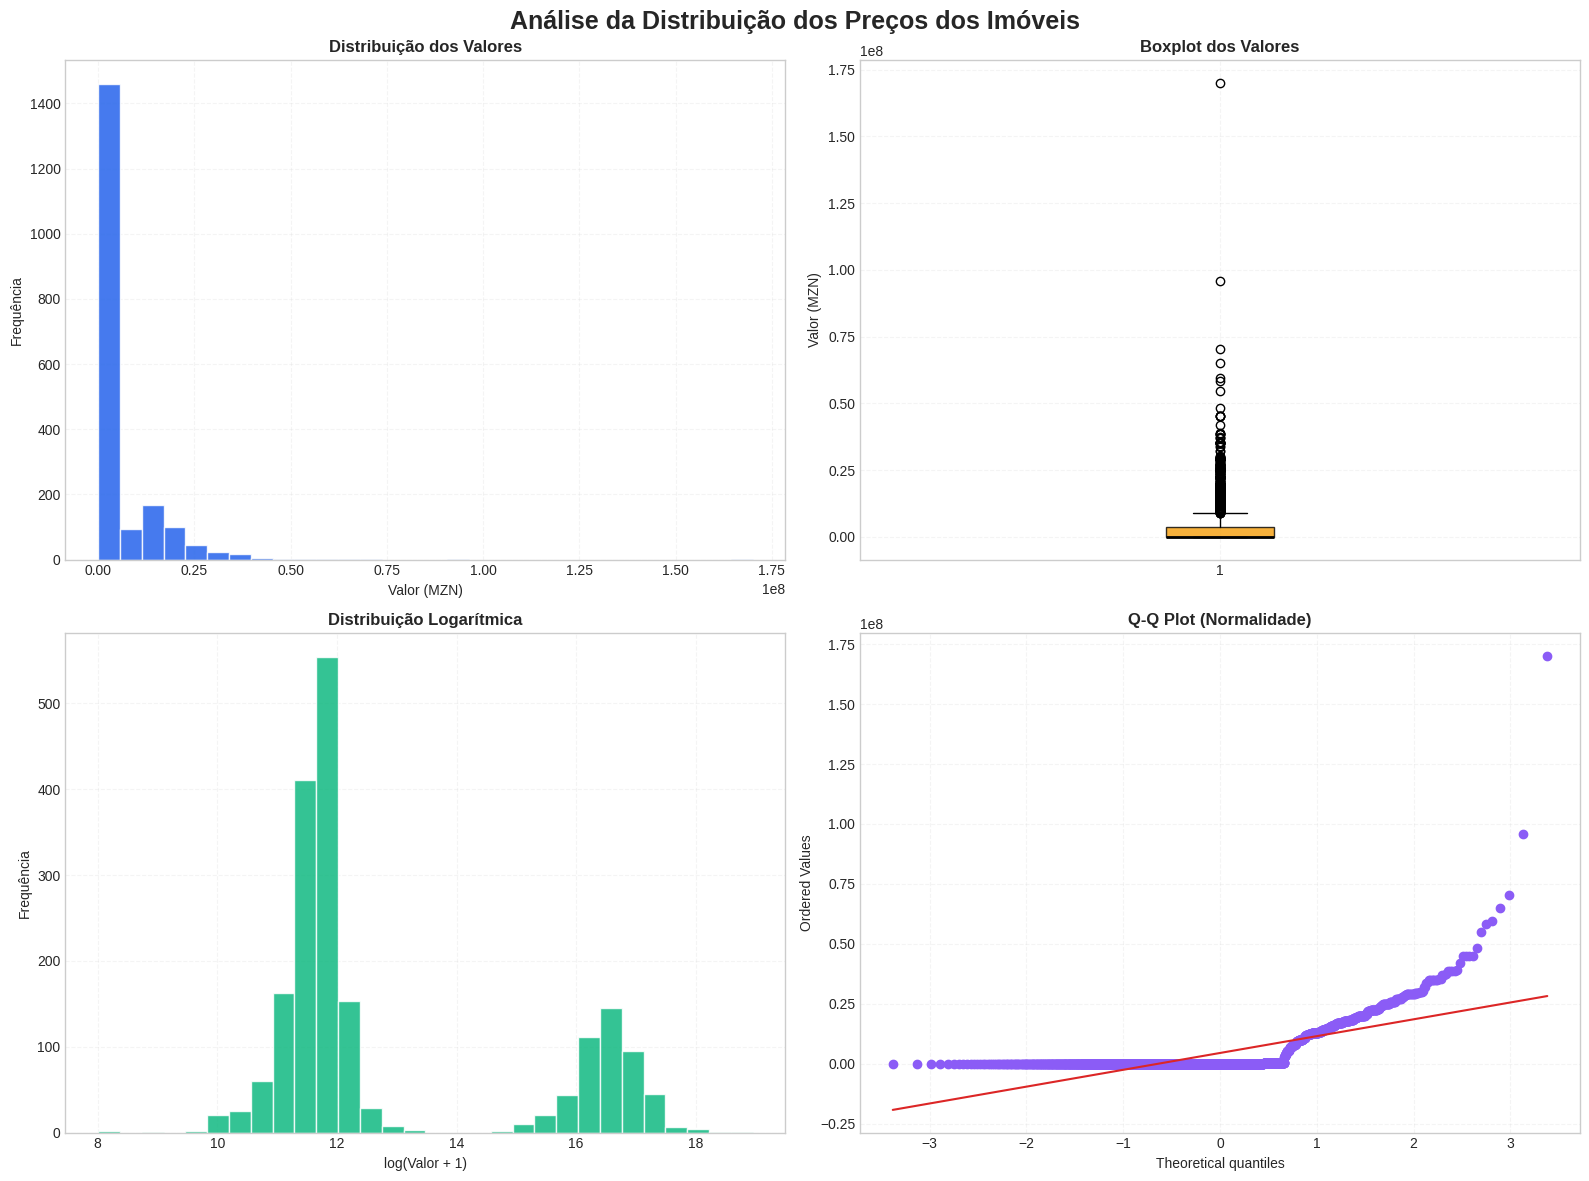

In [55]:
fig, axes = analisar_distribuicao_precos(imoveis)
plt.show()

### Disribuição por Tipo e Estado


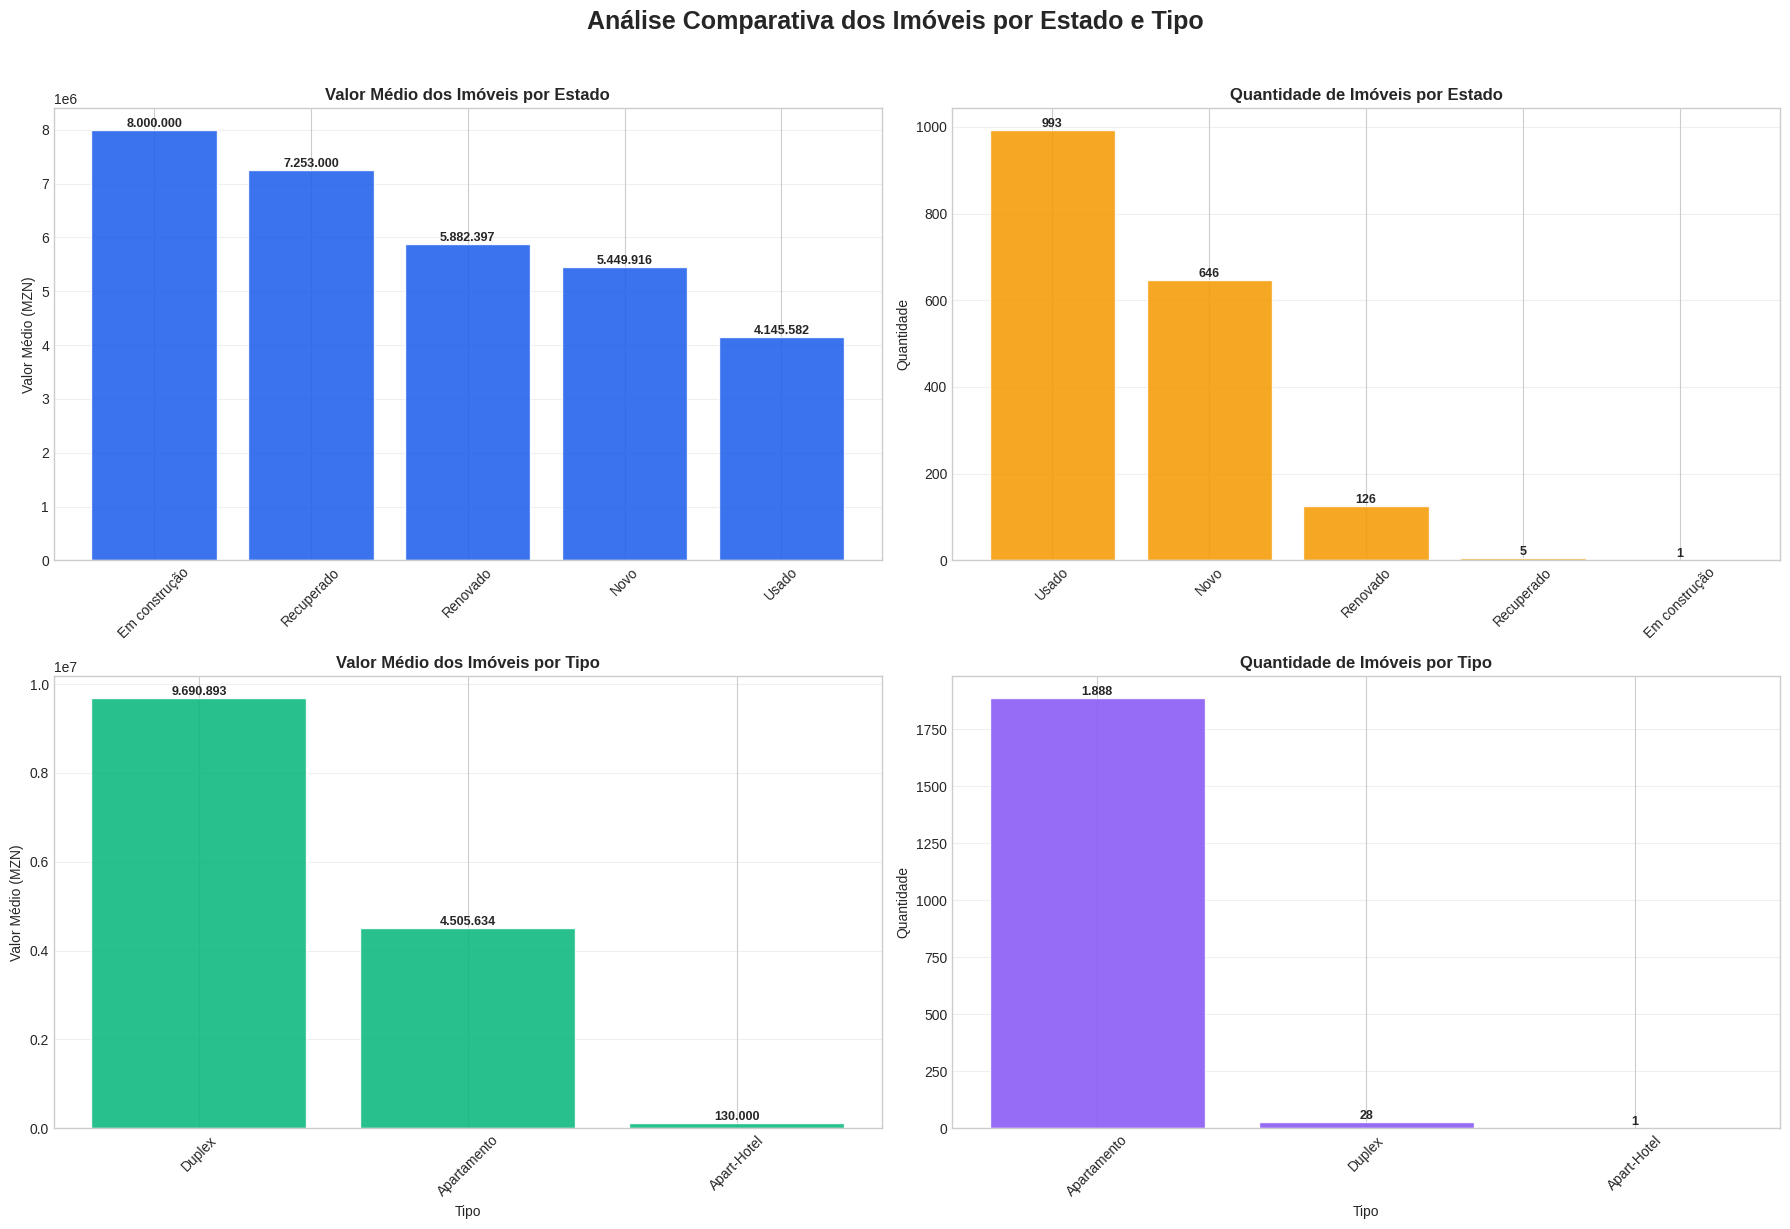

In [56]:
fig, axes = analisar_estado_tipo_imoveis(imoveis)

plt.show()

### Localização Geográfica

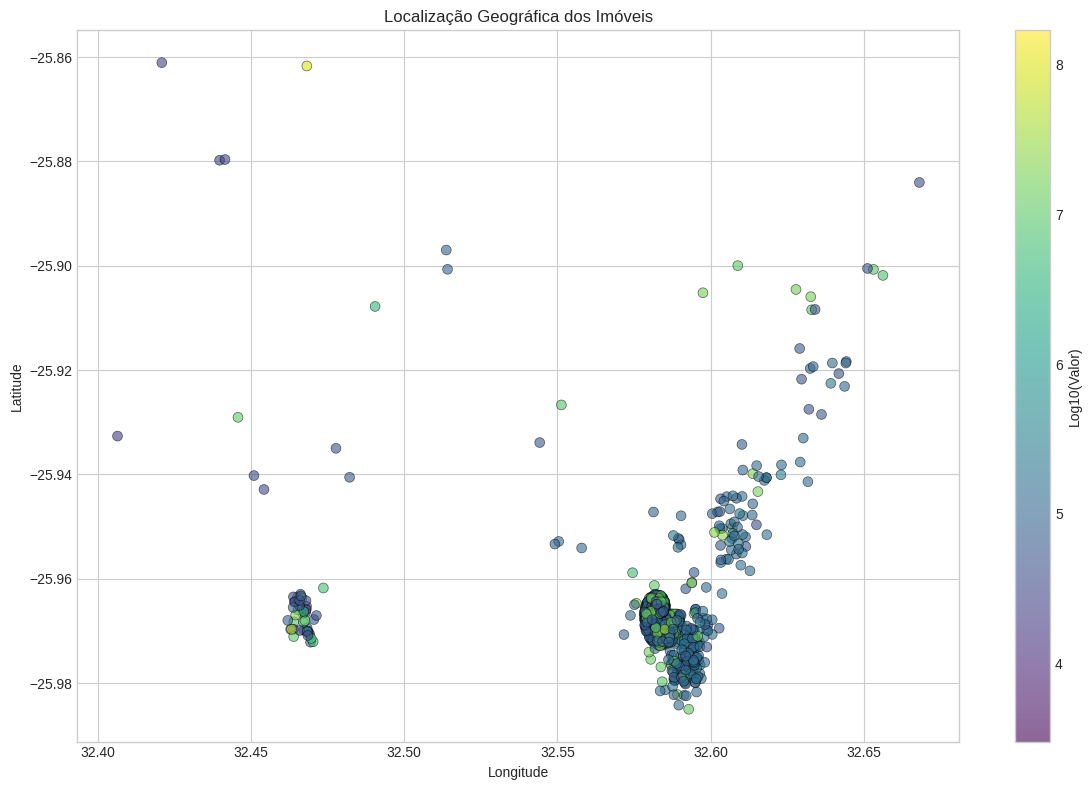

In [57]:
fig, ax = plotar_mapa_imoveis(imoveis)

plt.show()

### Características extraídas


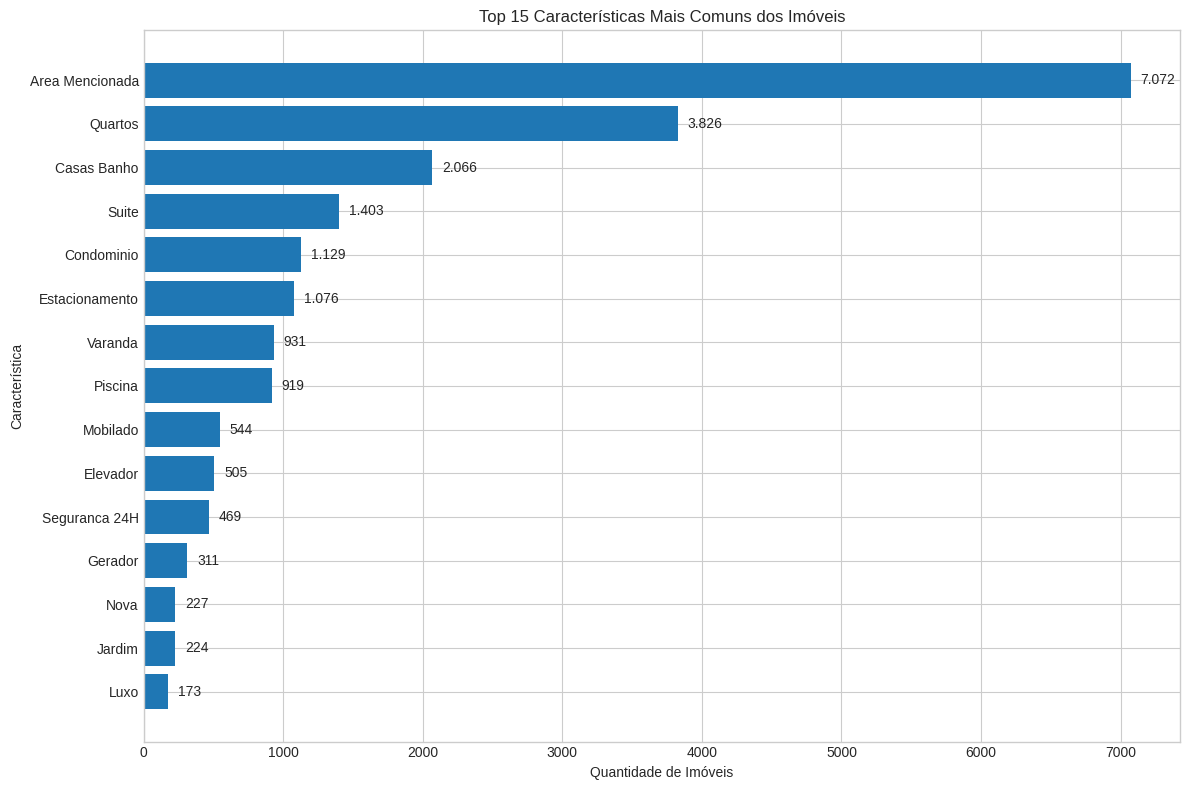

In [58]:
tabela, fig, ax = analisar_caracteristicas_imoveis(imoveis)

plt.show()

### Correlação

Os resultados demonstram que a **área do imóvel**, o **número de quartos** e a **dimensão em metros quadrados** são os factores que apresentam maior influência no valor dos imóveis analisados. As restantes características possuem impacto reduzido quando analisadas individualmente.

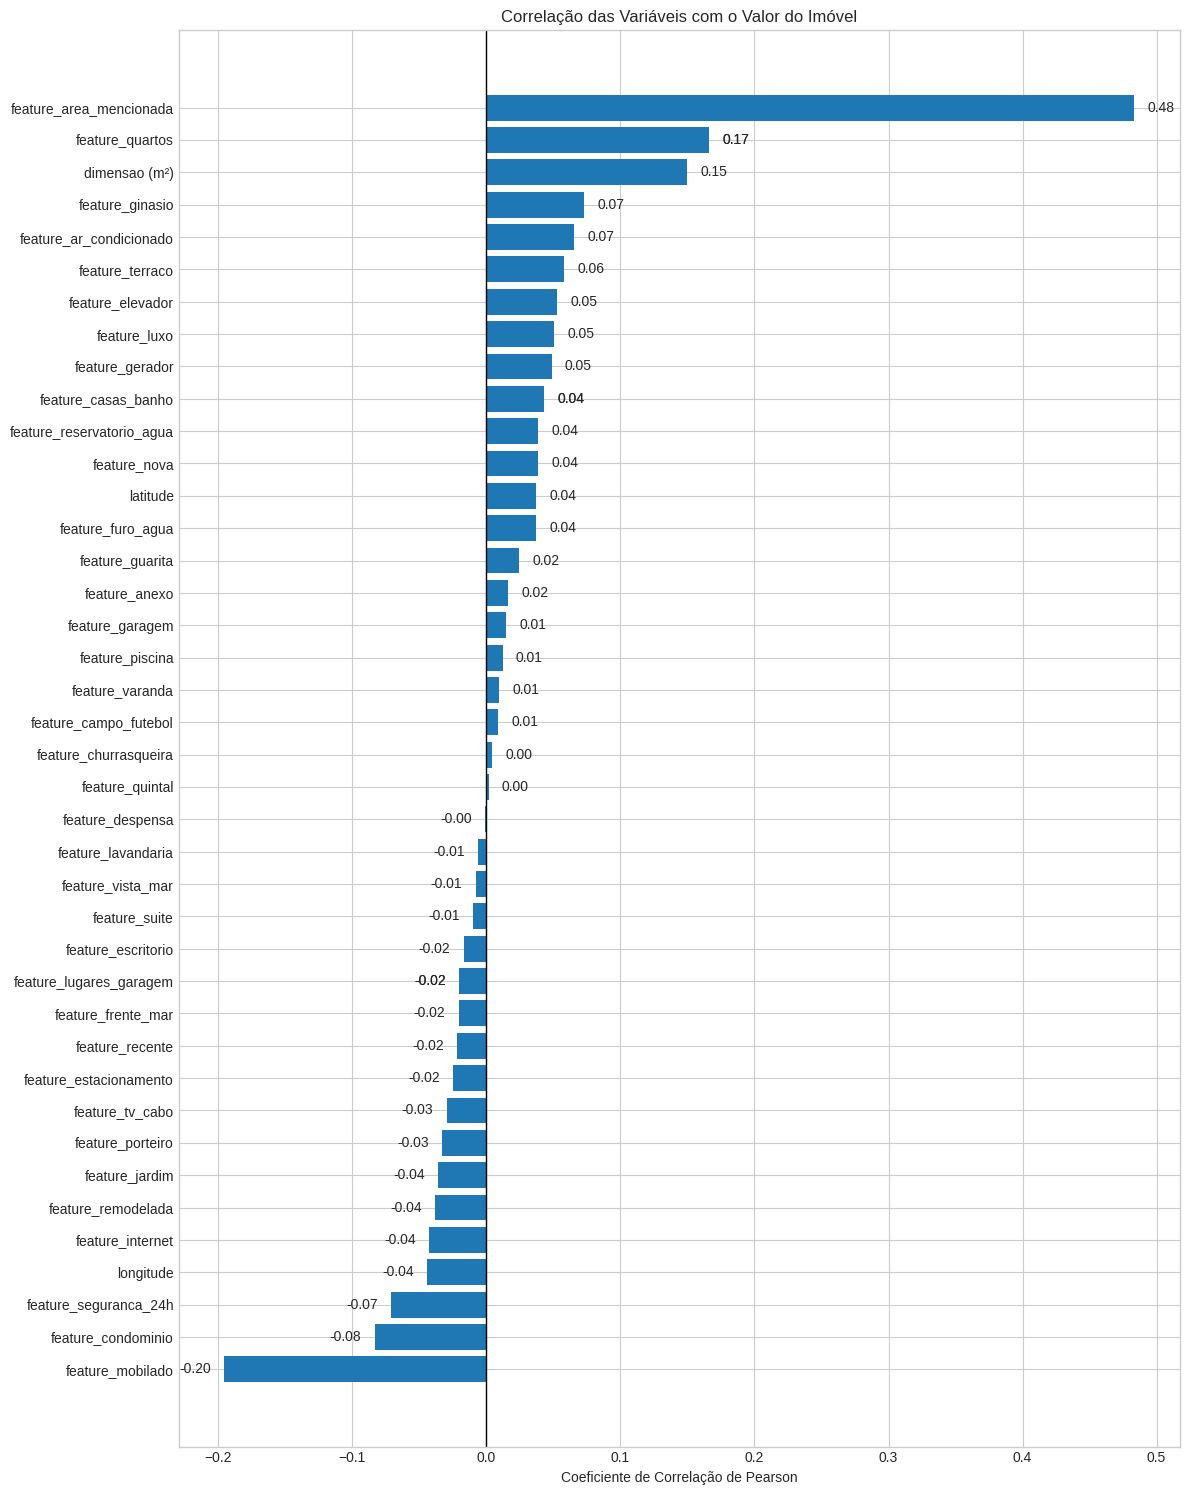

In [59]:
tabela_corr, fig, ax = analisar_correlacao_valor(imoveis)

plt.show()

---

In [60]:
imoveis.head()

,id,valor,descricao,latitude,longitude,estado,dimensao (m²),tipo_base,quartos_base,extras,config_especial,feature_quartos,feature_casas_banho,feature_lugares_garagem,feature_area_mencionada,feature_piscina,feature_jardim,feature_quintal,feature_churrasqueira,feature_campo_futebol,feature_ginasio,feature_seguranca_24h,feature_porteiro,feature_guarita,feature_condominio,feature_mobilado,feature_ar_condicionado,feature_ventilador,feature_internet,feature_tv_cabo,feature_garagem,feature_estacionamento,feature_elevador,feature_gerador,feature_reservatorio_agua,feature_furo_agua,feature_poco,feature_anexo,feature_escritorio,feature_lavandaria,feature_despensa,feature_varanda,feature_terraco,feature_suite,feature_vista_mar,feature_vista_rio,feature_frente_mar,feature_luxo,feature_nova,feature_remodelada,feature_recente,feature_energia_solar
0,71b8efa2083efe90f9f316fcbe35c0c2,24800000.0,Vender : Apartamento T3 Penthouse mobiliado na...,-25.971376,32.585460,Usado,220.0,Apartamento,3,0,NaN,3.0,NaN,0.0,NaN,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,b9c26f9e13ab754e235c742c047be54e,11000000.0,"Bairro da Sommerchield, Av. Mao Tsé Tung, próx...",-25.968346,32.579530,Usado,184.0,Apartamento,3,0,NaN,NaN,3.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,1ce001a5500f13814b3ca4ed57826e10,13500000.0,Vender : Excelente Apartamento T1 localizado n...,-25.966393,32.584436,Novo,110.0,Apartamento,1,0,NaN,1.0,1.0,0.0,NaN,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,16e183b6d93594bef480c561595a3b19,5600000.0,Endereço com alguns detalhes:\n\n\n\n\n\n Bair...,-25.971683,32.587328,Renovado,144.0,Apartamento,2,0,NaN,NaN,NaN,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,643acd0e4b65b7e47de0fe9e7b15ecfa,22500000.0,Apartamento de luxo no condomínio Roi residenc...,-25.964291,32.584357,Novo,180.0,Apartamento,3,0,NaN,NaN,NaN,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [61]:
# Salvar dataset tratado
imoveis.to_csv(saida_imoveis, index=False)

---
# *V. Modelagem*

## i. K-Means

Nesta secção vamos utilizar o algoritmo **K-Means** para agrupar imóveis semelhantes e, posteriormente, identificar os imóveis mais próximos dentro de cada grupo para gerar recomendações.

#### Tipo de Transacção

O sistema identifica automaticamente se o imóvel é:

* Venda;
* Arrendamento;
* Desconhecido.

A identificação é feita através da descrição do anúncio.

Exemplo:

**Descrição:**

> Arrenda-se apartamento T2 mobilado.

Resultado:

> Tipo de transacção: Aluguer

---

#### Agrupamento dos Imóveis

O algoritmo K-Means cria grupos de imóveis com características semelhantes.

Exemplo simplificado:

**Cluster 1**

* Apartamentos pequenos para aluguer.

**Cluster 2**

* Moradias familiares para venda.

**Cluster 3**

* Imóveis de luxo com piscina.

**Cluster 4**

* Terrenos.

Desta forma, imóveis semelhantes ficam agrupados no mesmo cluster.

---

#### Geração das Recomendações

Após identificar o cluster adequado, o sistema procura os imóveis mais semelhantes dentro desse grupo.

Por exemplo:

Um utilizador visualiza um apartamento T3 com:

* 3 quartos;
* 150 m²;
* Piscina;
* Arrendamento.

O sistema procura outros imóveis com características próximas e apresenta as melhores opções.

---

#### Características Utilizadas

O modelo considera diversos atributos dos imóveis.

**Informações Básicas**

* Valor;
* Latitude;
* Longitude;
* Dimensão;
* Número de quartos.

**Características do Imóvel**

* Piscina;
* Jardim;
* Garagem;
* Segurança 24 horas;
* Condomínio;
* Ar condicionado;
* Mobilado;
* Lavandaria;
* Varanda;
* Terraço;
* Entre outras.

**Características Categóricas**

* Tipo do imóvel;
* Estado do imóvel;
* Tipo de transacção.

---

#### Exemplo de Utilização

Suponha que um utilizador procura:

* Apartamento;
* 3 quartos;
* 150 m²;
* Piscina;
* Valor aproximado de 60.000 MZN;
* Arrendamento.

O sistema analisa estas preferências e procura imóveis semelhantes no conjunto de dados.

Exemplo de recomendação:

| ID  | Tipo        | Quartos | Valor  |
| --- | ----------- | ------- | ------ |
| 110 | Apartamento | 3       | 58.000 |
| 320 | Apartamento | 3       | 62.000 |
| 451 | Apartamento | 2       | 65.000 |

---

In [62]:
print("Carregando dados...")
df = carregar_dados(saida_imoveis)
print(f"{len(df)} imóveis carregados.")
print("\nDistribuição por tipo de transação (extraído do texto):")
print(df["tipo_transacao"].value_counts())

Carregando dados...
1917 imóveis carregados.

Distribuição por tipo de transação (extraído do texto):
tipo_transacao
Aluguer         1045
desconhecido     476
Venda            396
Name: count, dtype: int64


In [63]:
print("Treinando modelo KMeans...")
df_com_cluster, preprocessador, kmeans, X = treinar_modelo(df, n_clusters=None)

Treinando modelo KMeans...
Gráfico salvo em 'escolha_k.png'
Melhor k segundo silhouette score: 11


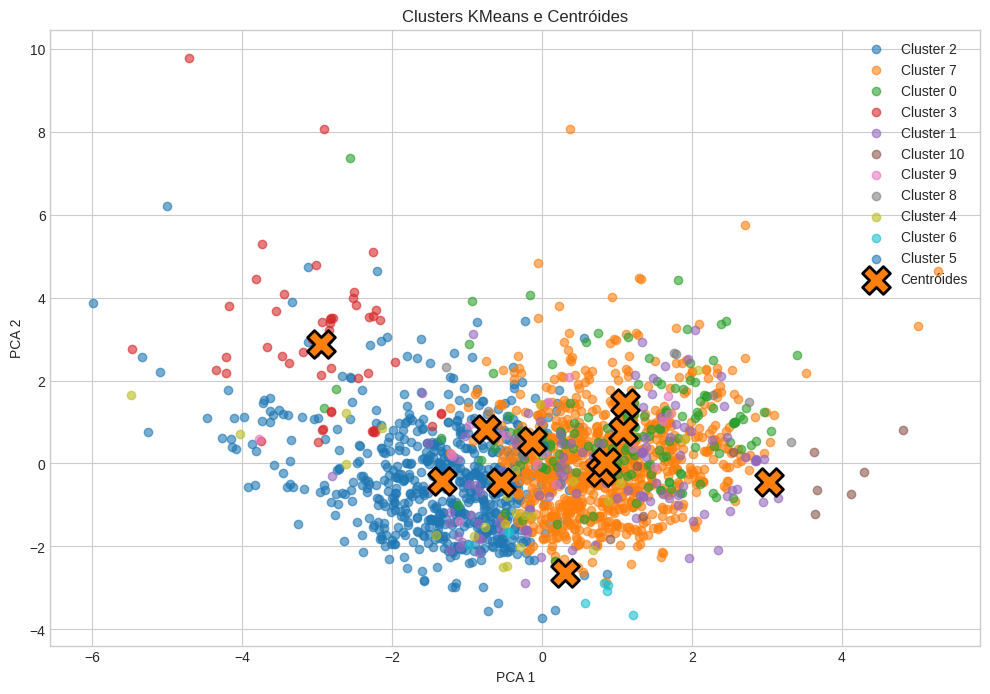

In [64]:
# Visualização
plotar_clusters_com_centroides(
    X,
    df_com_cluster,
    kmeans
)

In [65]:
print("Distribuição de imóveis por cluster:")
print(df_com_cluster["cluster"].value_counts().sort_index())

Distribuição de imóveis por cluster:
cluster
0     154
1     113
2     653
3      52
4      27
5       3
6       8
7     869
8       9
9      19
10     10
Name: count, dtype: int64


In [66]:
# Salvar modelo e criar recomendador
salvar_modelo_knn(preprocessador, kmeans, df_com_cluster)

recomendador = RecomendadorImoveis(df_com_cluster, preprocessador, kmeans, X)

Modelo salvo em 'modelo_imoveis.joblib'


In [67]:
# Exemplo 1: recomendar imóveis semelhantes a um imóvel existente
id_exemplo = df_com_cluster[COLUNA_ID].iloc[300]
print(f"\nRecomendações para o imóvel id={id_exemplo}:")
print(recomendador.recomendar_por_id(id_exemplo, n=5))


Recomendações para o imóvel id=2807fb7c0afde7f9226e04a6e44a6c1b:
                                 id     valor tipo_transacao estado  \
0  03efb00ff398e246b35c1d243a7073bb  135000.0        Aluguer  Usado   
1  e8cac66d22c7c9582302e555888db0d9  154800.0        Aluguer  Usado   
2  2b3701a877617d5d533d6e39f8516bd8  135000.0        Aluguer  Usado   
3  fbdcc4ead3dffa76fae36216248f96d2  135000.0        Aluguer  Usado   
4  474714446b1fbc1a552a47f724087473  148350.0        Aluguer   Novo   

     tipo_base  dimensao (m²)  quartos_base  cluster  distancia  
0  Apartamento          180.0           3.0        1   0.147304  
1  Apartamento          190.0           3.0        1   0.239759  
2  Apartamento          190.0           3.0        1   0.302237  
3  Apartamento          190.0           3.0        1   0.320742  
4  Apartamento          200.0           3.0        1   1.485551  


In [68]:
# Exemplo 2: recomendar a partir de preferências do utilizador
preferencias_exemplo = {
    "valor": 125_000,
    "latitude": df_com_cluster["latitude"].mean(),
    "longitude": df_com_cluster["longitude"].mean(),
    "dimensao (m²)": 150,
    "quartos_base": 2,
    "estado": df_com_cluster["estado"].mode()[0],
    "tipo_base": df_com_cluster["tipo_base"].mode()[0],
    "tipo_transacao": "Aluguer",
    "feature_piscina": 0,
    "feature_jardim": 0,
}
print("\nRecomendações com base em preferências:")
print(recomendador.recomendar_por_preferencias(preferencias_exemplo, n=5))


Recomendações com base em preferências:
                                 id     valor tipo_transacao estado  \
0  897cf54f69db84e4b6349641809e34b1  161250.0        Aluguer  Usado   
1  0d143e15029231854c71ecfb7433bf4b  135000.0        Aluguer  Usado   
2  7df8f8f003b6e5d6ac3ae4c2ee956f7f  120000.0        Aluguer  Usado   
3  44b4c99f0cac3682a7cf3cb81c846661   90000.0        Aluguer  Usado   
4  353aa9006b86e88b99e8b4ac164671f0  161250.0        Aluguer   Novo   

     tipo_base  dimensao (m²)  quartos_base  cluster  distancia  
0  Apartamento          120.0           2.0        7   0.949588  
1  Apartamento          190.0           3.0        7   1.408812  
2  Apartamento          190.0           3.0        7   1.615293  
3  Apartamento            0.0           2.0        7   1.623014  
4  Apartamento          140.0           2.0        7   1.623334  


---

</br>

## ii. Content-Based Filtering

#### Processamento da Descrição do Imóvel

Além das colunas da base de dados, o sistema também analisa o texto da descrição.

Exemplo:

> Apartamento moderno com vista para o mar, piscina, jardim e segurança permanente.

A descrição é transformada em informação numérica através da técnica TF-IDF.

Desta forma, o sistema consegue perceber que anúncios com palavras semelhantes possuem características semelhantes.

---

#### Cálculo da Similaridade

Após transformar os imóveis em vectores numéricos, o sistema calcula a semelhança entre eles utilizando Similaridade de Cosseno.

Quanto maior o valor da similaridade, mais parecidos são os imóveis.

Exemplo:

| Imóvel | Similaridade |
| ------ | ------------ |
| A      | 0.95         |
| B      | 0.88         |
| C      | 0.72         |
| D      | 0.40         |

Neste caso, os imóveis A e B seriam os mais recomendados.

---

#### Diferença em Relação ao Sistema com K-Means

O sistema anterior utilizava agrupamento (clustering).

Primeiro criava grupos de imóveis e depois procurava imóveis semelhantes dentro desses grupos.

Neste sistema não existem clusters.

Todos os imóveis podem ser comparados directamente.

Isto permite recomendações mais precisas, especialmente em catálogos de dimensão moderada.

---

#### Avaliação do Sistema

**Precision@K**

Mede a percentagem de recomendações relevantes.

Exemplo:

Se o sistema recomendar 10 imóveis e 7 forem relevantes:

```text
Precision@10 = 70%
```


**Recall@K**

Mede quantos imóveis relevantes foram encontrados pelo sistema.


**F1-Score**

Combina Precision e Recall numa única métrica.


**nDCG@K**

Avalia a qualidade da ordenação das recomendações.

Recomendações mais relevantes devem aparecer nas primeiras posições.


**Cobertura do Catálogo**

Mede quantos imóveis diferentes aparecem nas recomendações.

Maior cobertura significa menor tendência para recomendar sempre os mesmos imóveis.


**Diversidade**

Mede o quão diferentes são os imóveis recomendados entre si.

Uma boa diversidade evita listas demasiado repetitivas.

---

In [69]:
print("Carregando dados...")
df = carregar_dados(saida_imoveis)
print(f"{len(df)} imóveis carregados.")
print("\nDistribuição por tipo de transação (extraído do texto):")
print(df["tipo_transacao"].value_counts())

Carregando dados...
1917 imóveis carregados.

Distribuição por tipo de transação (extraído do texto):
tipo_transacao
Aluguer         1045
desconhecido     476
Venda            396
Name: count, dtype: int64


In [70]:
print("Construindo recomendador baseado em conteúdo (estrutura + texto)...")
recomendador = RecomendadorConteudo(df)
salvar_modelo(recomendador)

Construindo recomendador baseado em conteúdo (estrutura + texto)...
Modelo salvo em 'modelo_content_based.joblib'


In [71]:
print("Construindo gabarito de relevância heurística para avaliação...")
matriz_relevancia = construir_matriz_relevancia(df)
n_com_gabarito = (matriz_relevancia.sum(axis=1) > 0).sum()
print(f"{n_com_gabarito} de {len(df)} imóveis têm pelo menos um item 'relevante' "
      f"segundo a heurística (necessário para entrar nas métricas).")

print("\nAvaliando o recomendador baseado em conteúdo...")
relatorio_conteudo = avaliar_recomendador(recomendador, df, matriz_relevancia)
relatorio_conteudo.insert(0, "recomendador", "Content-Based (estrutura+texto)")

print("Avaliando o baseline aleatório (para comparação)...")
baseline = RecomendadorAleatorio(df)
relatorio_baseline = avaliar_recomendador(baseline, df, matriz_relevancia)
relatorio_baseline.insert(0, "recomendador", "Aleatório (baseline)")

Construindo gabarito de relevância heurística para avaliação...
1895 de 1917 imóveis têm pelo menos um item 'relevante' segundo a heurística (necessário para entrar nas métricas).

Avaliando o recomendador baseado em conteúdo...
Avaliando o baseline aleatório (para comparação)...


In [72]:
relatorio_final = pd.concat([relatorio_conteudo, relatorio_baseline], ignore_index=True)
pd.set_option("display.width", 160)
print("\n=== RELATÓRIO DE AVALIAÇÃO ===")
print(relatorio_final.round(4).to_string(index=False))
relatorio_final.to_csv("relatorio_avaliacao.csv", index=False)
print("\nRelatório salvo em 'relatorio_avaliacao.csv'")


=== RELATÓRIO DE AVALIAÇÃO ===
                   recomendador  k  n_itens_avaliados  precision@k  recall@k   f1@k  ndcg@k  similaridade_media@k  diversidade@k  cobertura_catalogo@k
Content-Based (estrutura+texto)  5               1895       0.5682    0.0368 0.0477  0.5940                0.6363         0.4269                0.9478
Content-Based (estrutura+texto) 10               1895       0.5225    0.0576 0.0659  0.5603                0.5767         0.5012                0.9802
           Aleatório (baseline)  5               1895       0.3091    0.0057 0.0107  0.3074                   NaN            NaN                0.9306
           Aleatório (baseline) 10               1895       0.3064    0.0116 0.0205  0.3062                   NaN            NaN                0.9776

Relatório salvo em 'relatorio_avaliacao.csv'


In [73]:
# Exemplo 1: recomendar imóveis semelhantes a um imóvel existente
id_exemplo = df[COLUNA_ID].iloc[300]
print(f"\nRecomendações (content-based) para o imóvel id={id_exemplo}:")
print(recomendador.recomendar_por_id(id_exemplo, n=5))


Recomendações (content-based) para o imóvel id=2807fb7c0afde7f9226e04a6e44a6c1b:
                                 id     valor tipo_transacao estado    tipo_base  dimensao (m²)  quartos_base  similaridade
0  2b3701a877617d5d533d6e39f8516bd8  135000.0        Aluguer  Usado  Apartamento          190.0           3.0      0.973065
1  67e788878e19089a2550ef39fecb0ec3  150000.0        Aluguer  Usado  Apartamento            0.0           3.0      0.958444
2  e8cac66d22c7c9582302e555888db0d9  154800.0        Aluguer  Usado  Apartamento          190.0           3.0      0.910520
3  fbdcc4ead3dffa76fae36216248f96d2  135000.0        Aluguer  Usado  Apartamento          190.0           3.0      0.893346
4  474714446b1fbc1a552a47f724087473  148350.0        Aluguer   Novo  Apartamento          200.0           3.0      0.891191


In [74]:
# Exemplo 2: recomendar a partir de preferências + descrição livre em texto
preferencias_exemplo = {
    "valor": 60000,
    "latitude": df["latitude"].mean(),
    "longitude": df["longitude"].mean(),
    "dimensao (m²)": 150,
    "quartos_base": 3,
    "estado": df["estado"].mode()[0],
    "tipo_base": df["tipo_base"].mode()[0],
    "tipo_transacao": "Aluguer",
    "feature_piscina": 0,
    "feature_jardim": 0,
}
descricao_livre_exemplo = "apartamento moderno com vista para o mar, piscina e segurança 24 horas"
print("\nRecomendações (content-based) com base em preferências + descrição livre:")
print(recomendador.recomendar_por_preferencias(
    preferencias_exemplo, descricao_livre=descricao_livre_exemplo, n=5
))


Recomendações (content-based) com base em preferências + descrição livre:
                                 id     valor tipo_transacao estado    tipo_base  dimensao (m²)  quartos_base  similaridade
0  0d143e15029231854c71ecfb7433bf4b  135000.0        Aluguer  Usado  Apartamento          190.0           3.0      0.672572
1  7df8f8f003b6e5d6ac3ae4c2ee956f7f  120000.0        Aluguer  Usado  Apartamento          190.0           3.0      0.653723
2  897cf54f69db84e4b6349641809e34b1  161250.0        Aluguer  Usado  Apartamento          120.0           2.0      0.638830
3  7efe2d55dd6485f2019fb277cc405b6d   45000.0        Aluguer  Usado  Apartamento            0.0           3.0      0.630867
4  cb2f4d65c8507b13055be0d21ced8aa1   75000.0        Aluguer  Usado  Apartamento            0.0           3.0      0.594658


---

</br>

<br/>

# *VI. Comparação dos Modelos e Escolha do Modelo Final*

### Síntese das Duas Abordagens

O **modelo K-Means** parte do princípio de que imóveis semelhantes tendem a agrupar-se naturalmente no espaço de características (valor, localização, dimensão, número de quartos e demais atributos binários e categóricos). Definido o número óptimo de clusters através do silhouette score (k = 11), cada novo pedido de recomendação é primeiro atribuído a um cluster e, só depois, comparado com os restantes imóveis desse mesmo cluster através do algoritmo dos vizinhos mais próximos.

O **modelo de Filtragem Baseada em Conteúdo** prescinde de qualquer partição prévia do catálogo. Cada imóvel é representado por dois vectores — um vector estrutural (os mesmos atributos numéricos e categóricos usados no K-Means) e um vector textual, obtido a partir da descrição do anúncio através de TF-IDF — que são combinados, com pesos configuráveis, numa única matriz de similaridade de cosseno entre todos os pares de imóveis do catálogo.

### Comparação Qualitativa

| Critério | K-Means (Clustering) | Filtragem Baseada em Conteúdo |
| --- | --- | --- |
| Princípio de funcionamento | Agrupa imóveis semelhantes; dentro do cluster atribuído, procura os vizinhos mais próximos | Calcula a similaridade de cosseno entre todos os pares de imóveis do catálogo |
| Atributos considerados | Valor, localização, dimensão, quartos, características binárias e variáveis categóricas | Os mesmos atributos estruturais, mais a descrição textual completa do anúncio |
| Uso da descrição textual | Apenas indirecto, para extrair características via expressões regulares | Pilar central do modelo, processado através de TF-IDF com bigramas |
| Pesquisa por texto livre | Não suportada | Suportada — o utilizador pode descrever o imóvel pretendido em linguagem natural |
| Âmbito da recomendação | Restrito aos imóveis do mesmo cluster (partição rígida do catálogo) | Todo o catálogo é elegível; a similaridade é calculada de forma contínua |
| Ajuste da importância dos critérios | Implícito, definido pela normalização e codificação das variáveis | Explícito, através dos pesos atribuídos à componente estrutural e à componente textual |
| Escalabilidade | Boa para catálogos muito grandes, pois a procura fica limitada ao cluster | Adequada a catálogos de dimensão moderada (matriz NxN); exigiria vizinhos aproximados por cosseno em catálogos muito maiores |
| Avaliação quantitativa disponível | Apenas indirecta (silhouette score sobre os clusters) | Directa, com Precision@k, Recall@k, F1@k, nDCG@k, diversidade e cobertura, face a um baseline aleatório |

### Avaliação Quantitativa

A qualidade do agrupamento do **K-Means** foi avaliada apenas de forma indirecta, através do silhouette score, que indicou k = 11 como o número óptimo de clusters. No entanto, a distribuição final dos imóveis pelos clusters revelou-se bastante desequilibrada: um único cluster concentra 869 dos 1917 imóveis (cerca de 45% do catálogo), enquanto vários outros contêm apenas entre 3 e 19 imóveis. Este desequilíbrio é uma limitação relevante, pois, dentro do cluster maior, a procura de vizinhos mais próximos tem um universo de candidatos muito mais amplo e heterogéneo do que nos clusters mais pequenos, o que tende a reduzir a consistência das recomendações entre diferentes imóveis de referência.

O **modelo de Filtragem Baseada em Conteúdo** foi avaliado directamente, recorrendo a um gabarito de relevância heurística (mesma tipologia de transacção, mesmo tipo de imóvel, preço e número de quartos semelhantes, e proximidade geográfica) e comparado com um baseline aleatório:

| Recomendador | k | Precision@k | Recall@k | F1@k | nDCG@k | Diversidade@k | Cobertura do Catálogo@k |
| --- | --- | --- | --- | --- | --- | --- | --- |
| Conteúdo (estrutura + texto) | 5 | 0,568 | 0,037 | 0,048 | 0,594 | 0,427 | 94,8% |
| Conteúdo (estrutura + texto) | 10 | 0,523 | 0,058 | 0,066 | 0,560 | 0,501 | 98,0% |
| Aleatório (baseline) | 5 | 0,309 | 0,006 | 0,011 | 0,307 | — | 93,1% |
| Aleatório (baseline) | 10 | 0,306 | 0,012 | 0,021 | 0,306 | — | 97,8% |

Os resultados mostram que o modelo baseado em conteúdo praticamente duplica a precisão e o nDCG do baseline aleatório, tanto para k = 5 como para k = 10, confirmando que as recomendações geradas reflectem de facto semelhanças relevantes entre imóveis, e não apenas o acaso. Os valores de recall são naturalmente baixos em ambos os casos, uma vez que o gabarito heurístico costuma identificar várias dezenas de imóveis potencialmente relevantes para cada imóvel de referência, dos quais apenas um pequeno subconjunto (5 ou 10) pode ser devolvido; por esta razão, a Precision@k e o nDCG@k são, neste contexto, os indicadores mais informativos sobre a qualidade do modelo. A cobertura do catálogo próxima dos 95–98% indica ainda que o modelo não se limita a recomendar repetidamente os mesmos imóveis, abrangendo praticamente todo o catálogo ao longo das diferentes consultas.

É importante notar que o K-Means não foi submetido ao mesmo protocolo de avaliação, pelo que não existe, neste projecto, uma comparação quantitativa directa, ponto a ponto, entre as duas abordagens segundo as mesmas métricas. Esta é assumida como uma limitação da presente análise e discutida nas conclusões desta secção.

### Análise Comparativa

Considerando os resultados e as características de cada abordagem, destacam-se os seguintes pontos:

- **Qualidade comprovada:** apenas o modelo de Filtragem Baseada em Conteúdo foi validado de forma objectiva face a um baseline, com ganhos substanciais de precisão e de qualidade de ordenação (nDCG).
- **Granularidade das recomendações:** o K-Means restringe as recomendações ao cluster atribuído, o que, dado o desequilíbrio observado entre clusters, pode prejudicar a qualidade das sugestões nos clusters mais pequenos e tornar as recomendações pouco diferenciadas no cluster dominante. A Filtragem Baseada em Conteúdo avalia o catálogo na sua totalidade para cada pedido, evitando esta limitação estrutural.
- **Utilização da descrição do imóvel:** apenas o modelo de conteúdo aproveita plenamente a informação textual dos anúncios, permitindo ainda que o utilizador descreva em linguagem livre o tipo de imóvel pretendido — uma funcionalidade particularmente relevante num mercado, como o de Maputo, em que muita informação relevante (vista, acabamentos, segurança, mobília) surge apenas na descrição e não em campos estruturados.
- **Flexibilidade de configuração:** os pesos atribuídos à componente estrutural e à componente textual no modelo de conteúdo permitem ajustar facilmente o comportamento do sistema, algo que não tem equivalente directo no K-Means.
- **Custo computacional:** o K-Means tende a escalar melhor para catálogos muito maiores, uma vez que a procura de vizinhos ocorre apenas dentro do cluster atribuído. A matriz de similaridade completa usada na Filtragem Baseada em Conteúdo é viável para o volume actual de dados (cerca de 1900 imóveis), mas exigiria, no futuro, uma abordagem por vizinhos aproximados caso o catálogo cresça significativamente — limitação já antecipada no próprio código do projecto.

### Escolha do Modelo Final

Com base na análise anterior, o **modelo de Filtragem Baseada em Conteúdo (estrutura + texto)** é seleccionado como modelo final do sistema de recomendação. Esta escolha assenta principalmente em três factores: é o único modelo com desempenho validado quantitativamente, superando claramente um baseline aleatório; não está limitado por uma partição rígida do catálogo, que se mostrou desequilibrada no caso do K-Means; e aproveita a descrição textual dos anúncios, permitindo pesquisas mais naturais e alinhadas com a forma como os utilizadores costumam descrever as suas preferências.

O modelo K-Means não é descartado do projecto, mas passa a desempenhar um papel complementar e exploratório: continua a ser útil para fins de segmentação do mercado imobiliário de Maputo (por exemplo, identificar grupos de imóveis com perfis semelhantes para fins de análise ou de visualização), mas não é recomendado como motor principal de recomendação ao utilizador final.

### Limitações da Comparação e Trabalho Futuro

A comparação apresentada está sujeita a algumas limitações que devem ser consideradas em desenvolvimentos futuros do projecto. Em primeiro lugar, o gabarito de relevância utilizado na avaliação é heurístico, baseado em regras de negócio (tipo de transacção, tipo de imóvel, preço, número de quartos e distância geográfica), e não em comportamento real de utilizadores, pelo que reflecte uma noção de relevância plausível, mas não validada empiricamente. Em segundo lugar, o mesmo protocolo de avaliação (Precision@k, Recall@k, F1@k, nDCG@k, diversidade e cobertura) não foi aplicado ao modelo K-Means, o que impede uma comparação quantitativa directa entre as duas abordagens; a aplicação desta avaliação ao K-Means é, por isso, recomendada como próximo passo natural do projecto. Por fim, seria desejável complementar esta avaliação heurística com dados reais de interacção dos utilizadores (cliques, contactos, conversões), por exemplo através de testes A/B, de forma a confirmar em produção as conclusões aqui apresentadas.

<br/>

---

# *VII. Conclusão*


Este projecto teve como objectivo desenvolver e avaliar diferentes abordagens de sistemas de recomendação de imóveis para o mercado da cidade de Maputo, com vista à sugestão automática de imóveis semelhantes às preferências e aos imóveis previamente visualizados pelos utilizadores.

---

## Metodologia

A investigação foi desenvolvida em cinco fases principais:

1. **Recolha e Descrição dos Dados**: Obtenção de um conjunto de cerca de 1900 anúncios de imóveis para venda e arrendamento na cidade de Maputo, compilados a partir de plataformas imobiliárias online, seguida de uma análise inicial da sua qualidade.

2. **Limpeza e Engenharia de Atributos**: Tratamento de valores nulos e de valores de venda inconsistentes, normalização do tipo e da tipologia dos imóveis, e extracção de características adicionais (piscina, jardim, garagem, segurança, entre outras) directamente a partir da descrição textual dos anúncios.

3. **Análise Exploratória de Dados**: Estudo da distribuição dos preços, da relação entre o tipo e o estado dos imóveis, da sua localização geográfica e da correlação entre o valor e as restantes características, tendo-se identificado a área do imóvel, o número de quartos e a dimensão em metros quadrados como os factores de maior influência no preço.

4. **Modelação**: Implementação de duas abordagens distintas de recomendação — um modelo de agrupamento por **K-Means**, seguido de procura dos vizinhos mais próximos dentro de cada cluster, e um modelo de **Filtragem Baseada em Conteúdo**, que combina os atributos estruturais dos imóveis com a sua descrição textual através de TF-IDF e similaridade de cosseno.

5. **Avaliação e Comparação dos Modelos**: Avaliação quantitativa do desempenho dos modelos através das métricas Precision@k, Recall@k, F1-Score@k, nDCG@k, diversidade e cobertura do catálogo, com comparação face a um baseline aleatório, culminando na selecção do modelo mais adequado.

---

## Principais Descobertas

* O modelo de Filtragem Baseada em Conteúdo demonstrou um desempenho claramente superior ao de um baseline aleatório, praticamente duplicando os valores de Precision@k e de nDCG@k, o que confirma que as recomendações geradas reflectem semelhanças genuinamente relevantes entre imóveis.

* A descrição textual dos anúncios revelou-se uma fonte de informação valiosa, frequentemente complementar aos campos estruturados, contendo pormenores como vista, acabamentos, segurança ou mobília que influenciam de forma directa a percepção de semelhança entre imóveis.

* A área do imóvel, o número de quartos e a dimensão em metros quadrados confirmaram-se como os atributos com maior correlação com o valor, em linha com o que seria esperado para o mercado imobiliário em estudo.

* O agrupamento por K-Means, embora útil para uma segmentação exploratória do mercado, produziu clusters bastante desequilibrados, com um único cluster a concentrar quase metade do catálogo, o que limita a sua adequação como mecanismo principal de recomendação.

* A maior parte dos anúncios analisados corresponde a imóveis para arrendamento, sendo a venda uma parcela claramente minoritária do conjunto de dados recolhido.

---

## Limitações do Estudo

| Limitação | Descrição |
| --- | --- |
| **Âmbito Geográfico Restrito** | O estudo limitou-se a imóveis da cidade de Maputo, não tendo sido validado para outras regiões ou mercados imobiliários. |
| **Avaliação Heurística da Relevância** | A avaliação dos modelos baseou-se num gabarito de relevância construído a partir de regras de negócio, e não em comportamento real de utilizadores. |
| **Comparação Incompleta entre Modelos** | O modelo K-Means não foi submetido ao mesmo protocolo de avaliação quantitativa do modelo de conteúdo, o que impediu uma comparação directa, métrica a métrica, entre as duas abordagens. |
| **Representação Textual Limitada** | A descrição dos imóveis foi representada exclusivamente através de TF-IDF, não tendo sido exploradas representações semânticas mais avançadas. |
| **Escalabilidade da Solução** | O modelo de conteúdo assenta numa matriz de similaridade entre todos os pares de imóveis, abordagem que deixa de ser viável para catálogos muito maiores do que o utilizado neste projecto. |
| **Qualidade e Actualidade dos Dados** | Os dados foram recolhidos num único momento a partir de plataformas públicas, podendo conter imprecisões e não reflectindo necessariamente a evolução do mercado ao longo do tempo. |

---

## Recomendações para Pesquisas Futuras

* **Validação com Dados Reais de Utilizadores**: Substituir, ou complementar, o gabarito de relevância heurística por dados reais de interacção (cliques, contactos, conversões), eventualmente através de testes A/B em ambiente de produção.

* **Representações Semânticas do Texto**: Explorar representações textuais mais avançadas, como embeddings de frases ou modelos baseados em Transformers, em substituição ou em complemento do TF-IDF.

* **Sistemas Híbridos de Recomendação**: Investigar a combinação da Filtragem Baseada em Conteúdo com técnicas de Filtragem Colaborativa, à medida que for recolhido um volume suficiente de dados de interacção dos utilizadores.

* **Expansão Geográfica e Temporal**: Estender a recolha de dados a outras cidades e regiões, e actualizar periodicamente o conjunto de dados, de modo a aumentar a capacidade de generalização e a relevância prática do sistema.

* **Escalabilidade da Matriz de Similaridade**: Substituir o cálculo exaustivo da similaridade entre todos os pares de imóveis por técnicas de vizinhos aproximados, preparando o sistema para catálogos de maior dimensão.

---

## Por Fim

O modelo seleccionado — a Filtragem Baseada em Conteúdo — apresentou um desempenho satisfatório na tarefa de recomendação de imóveis e confirmou a viabilidade da utilização conjunta de atributos estruturais e de descrições textuais para este fim. Apesar das limitações identificadas, em particular o âmbito restrito à cidade de Maputo e a natureza heurística da avaliação realizada, este projecto estabelece uma base sólida para futuras investigações e para o eventual desenvolvimento de um sistema de recomendação de imóveis em contexto real.

<br/>


# *VIII. Conceitos Utilizados*

---

### Sistema de Recomendação

Um sistema de recomendação é uma ferramenta que sugere itens que possam ser do interesse do utilizador.

No contexto imobiliário, o objectivo é sugerir imóveis semelhantes àqueles que o cliente está a visualizar ou pesquisar.

**Exemplo:**

Um utilizador está interessado numa moradia T3 na Matola.

O sistema pode recomendar outras moradias T3 com preço, localização e características semelhantes.

---

### Clustering

Clustering é uma técnica de aprendizagem não supervisionada que agrupa elementos semelhantes.

O objectivo é identificar padrões existentes nos dados sem utilizar rótulos previamente definidos.

No projecto, os imóveis são agrupados de acordo com características como:

* Preço
* Localização
* Tipo de imóvel
* Número de quartos
* Dimensão
* Estado do imóvel

**Exemplo:**

Um grupo pode conter principalmente apartamentos para aluguer, enquanto outro pode conter moradias para venda.

---

### K-Means

K-Means é um algoritmo de clustering.

O seu objectivo é dividir os imóveis em grupos chamados **clusters**.

Cada cluster reúne imóveis com características semelhantes.

**Exemplo:**

| Cluster | Características predominantes |
| ------- | ----------------------------- |
| 0       | Apartamentos pequenos         |
| 1       | Moradias familiares           |
| 2       | Imóveis de luxo               |
| 3       | Terrenos                      |

Quando um imóvel é seleccionado, o sistema identifica primeiro o cluster ao qual ele pertence.

---

### Centróide

O centróide é o ponto central de um cluster.

Representa o perfil médio dos imóveis daquele grupo.

Durante o funcionamento do K-Means, cada imóvel é associado ao centróide mais próximo.

**Exemplo:**

Se um cluster contém moradias T3 entre 4 e 6 milhões de meticais, o centróide representa aproximadamente essas características médias.

---

### Nearest Neighbors (KNN)

Após identificar o cluster correcto, o sistema utiliza a técnica **Nearest Neighbors**.

Esta técnica procura os imóveis mais próximos do imóvel de referência.

Quanto menor a distância entre dois imóveis, maior a sua semelhança.

**Exemplo:**

Se o utilizador visualizar uma moradia T4 na Sommerschield, o sistema procura outros imóveis com características semelhantes dentro do mesmo cluster.

---

### Distância Euclidiana

A distância Euclidiana mede a proximidade entre dois imóveis considerando as suas características numéricas.

Quanto menor a distância, mais semelhantes são os imóveis.

**Exemplo:**

| Imóvel | Preço     | Quartos |
| ------ | --------- | ------- |
| A      | 5.000.000 | 3       |
| B      | 5.100.000 | 3       |

Como os valores são muito próximos, a distância calculada será pequena.

---

### Content-Based Filtering

Content-Based Filtering é uma abordagem que recomenda itens com base nas suas características.

Em vez de utilizar apenas grupos, o sistema analisa directamente os atributos do imóvel.

No projecto são utilizadas características como:

* Descrição do imóvel
* Preço
* Tipo
* Quartos
* Extras
* Localização
* Estado

**Exemplo:**

Se um imóvel possui:

* Piscina
* Jardim
* Garagem

o sistema procura outros imóveis que possuam características semelhantes.

---

### Processamento de Texto

As descrições dos imóveis contêm informação importante que não existe nas colunas estruturadas da base de dados.

Por isso, o texto é transformado em informação numérica que pode ser utilizada pelos algoritmos.

**Exemplo de descrição:**

> Moradia T4 com piscina, jardim, garagem e segurança 24 horas.

O sistema consegue identificar palavras relevantes como:

* piscina
* jardim
* garagem
* segurança

---

### TF-IDF

TF-IDF (*Term Frequency – Inverse Document Frequency*) é uma técnica utilizada para representar textos numericamente.

Ela atribui maior importância às palavras mais relevantes de cada descrição.

**Exemplo:**

Descrição 1:

> Moradia com piscina e jardim.

Descrição 2:

> Apartamento com piscina.

A palavra "jardim" recebe maior peso na primeira descrição porque ajuda a distinguir esse imóvel dos restantes.

---

### Vectorização

Vectorização é o processo de converter texto em números.

Os algoritmos de Machine Learning trabalham apenas com valores numéricos.

Após a vectorização, cada imóvel passa a ser representado por um conjunto de números.

**Exemplo:**

| Palavra | Valor |
| ------- | ----- |
| piscina | 0.75  |
| jardim  | 0.60  |
| garagem | 0.40  |

---

### Similaridade de Cosseno

A Similaridade de Cosseno mede o grau de semelhança entre dois imóveis.

O valor varia entre 0 e 1.

* 0 → completamente diferentes
* 1 → praticamente iguais

**Exemplo:**

| Imóvel A               | Imóvel B                        | Similaridade |
| ---------------------- | ------------------------------- | ------------ |
| Moradia T4 com piscina | Moradia T4 com piscina e jardim | 0.92         |
| Moradia T4             | Terreno                         | 0.08         |

Quanto maior a similaridade, maior a probabilidade de recomendação.

---

### Engenharia de Atributos (Feature Engineering)

Feature Engineering consiste na criação e preparação das características utilizadas pelos modelos.

No projecto foram realizadas actividades como:

* Tratamento de valores nulos
* Normalização de variáveis
* Codificação de variáveis categóricas
* Combinação de atributos estruturados e textuais

O objectivo é melhorar a qualidade das recomendações.

---

### Normalização

As variáveis possuem escalas diferentes.

Por exemplo:

| Variável | Valor     |
| -------- | --------- |
| Quartos  | 4         |
| Preço    | 5.000.000 |

Sem normalização, o preço dominaria os cálculos.

A normalização coloca todas as variáveis numa escala comparável.

---

### One-Hot Encoding

Alguns atributos são categóricos e precisam ser convertidos em números.

**Exemplo:**

| Tipo        |
| ----------- |
| Apartamento |
| Moradia     |
| Terreno     |

Após a codificação:

| Apartamento | Moradia | Terreno |
| ----------- | ------- | ------- |
| 1           | 0       | 0       |
| 0           | 1       | 0       |
| 0           | 0       | 1       |

---